# EXP-3 — Scenario 1A: Dynamics Classification with AST

This experiment investigates whether an **Audio Spectrogram Transformer (AST)** can reliably learn and predict **playing dynamics** in the SECD material when the musical condition is deliberately constrained.

At a high level, the goal is to determine whether the model can distinguish among a selected set of dynamics levels:

- pianissimo
- piano
- mezzo-piano
- forte
- fortissimo

while operating on samples restricted to a single playing condition, namely **arco-normal**.

The reasoning behind this design is to reduce unnecessary variability in the input space. By fixing the technique to arco-normal, the experiment attempts to isolate the dynamics-related information more clearly and make the classification problem more controlled. In other words, the model is not asked to solve dynamics recognition across all possible performance techniques at once, but within a narrower and more stable acoustic setting.

## What the experiment is trying to achieve

The experiment aims to evaluate whether dynamics can be learned as a robust audio classification target from mel-spectrogram representations using a transformer-based architecture. More specifically, it examines whether AST can capture the acoustic patterns associated with dynamic intensity differences across the string instruments represented in the dataset.

This is not framed as a broad musical understanding task. It is a focused supervised classification experiment whose purpose is to test whether the chosen pipeline can extract discriminative information for dynamics under controlled conditions.

## How the experiment approaches the problem

The overall strategy is the following:

1. **Restrict the dataset to arco-normal samples only**  
   This reduces variation caused by technique changes and makes the dynamics classification task more controlled.

2. **Keep only a focused set of dynamics labels**  
   The experiment uses a selected subset of dynamics categories so that the label space remains consistent and meaningful.

3. **Convert the audio into a representation suitable for AST**  
   The model operates on mel-spectrogram-like inputs prepared in a format compatible with the Audio Spectrogram Transformer.

4. **Train a transformer-based classifier**  
   A pretrained AST backbone is adapted and fine-tuned on this task so that it can learn patterns relevant to dynamics prediction.

5. **Evaluate performance on held-out data**  
   The experiment measures how well the trained model generalizes to validation data using standard classification metrics such as loss, accuracy, and macro F1-score.

## Intended outcome

If the experiment performs well, it provides evidence that dynamics recognition in this constrained setting is learnable by the AST-based pipeline. That would support the use of this scenario as a clean and controlled benchmark for studying dynamics-related classification behavior in the SECD framework.

At the same time, the experiment remains intentionally narrow in scope. Its purpose is not to solve all expressive-performance recognition conditions at once, but to test one carefully defined subproblem under reduced variability.

In [ ]:
!pip install numpy pandas matplotlib scipy scikit-learn scikit-multilearn transformers psutil ipython --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 41.8 MB/s eta 0:00:00


In [ ]:
!pip install accelerate --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 11.3 MB/s eta 0:00:00


## Cell 0 — Path ConfigurationCentral path registry for the entire notebook.
Every downstream cellreads paths from the `paths` object defined here — no hardcodeddirectories anywhere else.Update **only this cell** when migrating between machines.

In [ ]:
# Cell 0 — Path Configuration

import os
from dataclasses import dataclass, field
from pathlib import Path

@dataclass
class ExpPaths:
    base:       str = "/home/aggelosger"
    cache_root: str = ""
    outdir:     str = ""
    split_dir:  str = ""
    csv_dirs:   list = field(default_factory=list)

    def __post_init__(self):
        self.cache_root = os.path.join(self.base, "mel_cache_ast16k_256")
        self.outdir     = os.path.join(self.base, "EXP3_AST_DYN")
        self.split_dir  = os.path.join(self.outdir, "exp3_splits")

        self.csv_dirs = []
        for group in [
            "harmonic_intervals_loose", "harmonic_intervals_strict",
            "triads_loose", "triads_strict",
            "7th_chords_loose", "7th_chords_strict",
        ]:
            d = os.path.join(self.base, group, "csv")
            if os.path.isdir(d):
                self.csv_dirs.append(d)

    def verify(self):
        errors = []
        if not os.path.isdir(self.cache_root):
            errors.append(f"Cache not found: {self.cache_root}")
        if not self.csv_dirs:
            errors.append("No CSV directories found")
        for d in self.csv_dirs:
            csvs = [f for f in os.listdir(d)
                    if f.endswith(".csv") and "-original" not in f]
            if not csvs:
                errors.append(f"No usable CSVs in {d}")
        if errors:
            for e in errors:
                print(f"  ❌ {e}")
            raise RuntimeError("Path verification failed")

        os.makedirs(self.outdir, exist_ok=True)
        os.makedirs(self.split_dir, exist_ok=True)

        all_csvs = []
        for d in self.csv_dirs:
            all_csvs += [os.path.join(d, f) for f in os.listdir(d)
                         if f.endswith(".csv") and "-original" not in f]

        print(f"  ✅ Base       : {self.base}")
        print(f"  ✅ Cache      : {self.cache_root}")
        print(f"  ✅ Output     : {self.outdir}")
        print(f"  ✅ Splits     : {self.split_dir}")
        print(f"  ✅ CSV dirs   : {len(self.csv_dirs)}")
        print(f"  ✅ CSV files  : {len(all_csvs)} (excluding -original)")
        return all_csvs

paths = ExpPaths()
all_csv_paths = paths.verify()
print(f"\n✅ Path configuration OK")

  ✅ Base       : /home/aggelosger
  ✅ Cache      : /home/aggelosger/mel_cache_ast16k_256
  ✅ Output     : /home/aggelosger/EXP3_AST_DYN
  ✅ Splits     : /home/aggelosger/EXP3_AST_DYN/exp3_splits
  ✅ CSV dirs   : 6
  ✅ CSV files  : 22 (excluding -original)

✅ Path configuration OK


## Cell 0.1 — Environment CheckPrints the active Python interpreter path and module search paths.
Run once at the start of a session to confirm the correctenvironment is active before loading any dependencies.

In [ ]:
import sys

print("Python interpreter:")
print(f"  {sys.executable}")
print("\nModule search paths:")
for p in sys.path:
    if p:
        print(f"  {p}")

Python interpreter:
  /usr/bin/python3

Module search paths:
  /usr/lib/python312.zip
  /usr/lib/python3.12
  /usr/lib/python3.12/lib-dynload
  /home/aggelosger/.local/lib/python3.12/site-packages
  /usr/local/lib/python3.12/dist-packages
  /usr/lib/python3/dist-packages


## Cell 0a — Execution Timestamp Helpers.
Two lightweight functions to track when each cell ran and how long it took.Call `cell_start("Cell X")` at the top and `cell_end("Cell X")` at the bottomof every cell. Output is a clean stamp with date, time, and duration.To remove all stamps before publishing, delete this cell and run:    sed -i '/cell_start(/d; /cell_end(/d' your_notebook.py

In [ ]:
# Cell 0a — Execution Timestamp Helpers

import time
from datetime import datetime

_CELL_START = {}

def cell_start(name: str):
    _CELL_START[name] = time.perf_counter()
    ts = datetime.now().strftime("%Y-%m-%d  %H:%M:%S")
    print(f"[{name}]  started  {ts}")
    print("-" * 60)

def cell_end(name: str):
    elapsed = time.perf_counter() - _CELL_START.get(name, time.perf_counter())
    ts = datetime.now().strftime("%Y-%m-%d  %H:%M:%S")
    h  = int(elapsed // 3600)
    m  = int((elapsed % 3600) // 60)
    s  = elapsed % 60
    dur = f"{h}h {m}m {s:.1f}s" if h else (f"{m}m {s:.1f}s" if m else f"{s:.1f}s")
    print("-" * 60)
    print(f"[{name}]  finished {ts}  |  duration: {dur}")

print("Timestamp helpers loaded. Use cell_start() and cell_end() in every cell.")

Timestamp helpers loaded. Use cell_start() and cell_end() in every cell.


## Cell 0b — Disable Timestamps Before Publishing
To remove all timestamp output before publishing, replace Cell 0a entirelywith the cell below. Every `cell_start()` and `cell_end()` call acrossthe notebook will then execute silently without any output.No other cell needs to be touched.

In [ ]:
# Cell 0b — Execution Timestamp Helpers (DISABLED for publishing)
# Replace Cell 0a with this block to silence all stamps.

# def cell_start(name: str): pass
# def cell_end(name: str):   pass

## Cell 1 — Server Snapshot (RAM · GPU · CPU · Disk)
Prints a full server status report in a single execution:- **CPU** — model, cores, frequency, current usage- **RAM** — used / free / cached / swap with visual bars- **GPU** — VRAM total / allocated / free, CUDA & cuDNN versions, SM count, compute capability- **Disk** — partition usage with visual bars- **File counts** — mel cache `.npy`, splits, run folders- **Environment** — Python / PyTorch / transformers / sklearn versions> Run at the start of every session to confirm the environment is healthy before training.

In [ ]:
# Cell 1 — Server Snapshot (RAM · GPU · CPU · Disk)

cell_start("Cell 1")
import os, platform, subprocess, shutil
import psutil, torch

def _bar(used, total, width=30):
    if total == 0: return "[" + "?" * width + "]"
    filled = int(width * used / total)
    pct = 100 * used / total
    bar = "█" * filled + "░" * (width - filled)
    return f"[{bar}] {pct:5.1f}%"

def _gb(n): return f"{n/1024**3:.2f} GB"
def _gb2(a, b): return f"{_gb(a)} / {_gb(b)}"

SEP  = "═" * 64
sep  = "─" * 64

print(f"\n{SEP}")
print(f"  🖥️  SERVER SNAPSHOT — {platform.node()}")
print(f"{SEP}")

# ── 1. CPU ────────────────────────────────────────────────────────
print(f"\n{'─'*64}")
print(f"  💻  CPU")
print(f"{'─'*64}")
cpu_model = platform.processor() or "N/A"
try:
    with open("/proc/cpuinfo") as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":")[1].strip()
                break
except: pass

phys_cores  = psutil.cpu_count(logical=False)
logic_cores = psutil.cpu_count(logical=True)
cpu_freq    = psutil.cpu_freq()
cpu_pct     = psutil.cpu_percent(interval=1, percpu=False)

print(f"  Model      : {cpu_model}")
print(f"  Cores      : {phys_cores} physical  /  {logic_cores} logical")
if cpu_freq:
    print(f"  Frequency  : {cpu_freq.current:.0f} MHz  (max {cpu_freq.max:.0f} MHz)")
print(f"  Usage now  : {cpu_pct:.1f}%  {_bar(cpu_pct, 100, 20)}")

# ── 2. RAM ───────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  🧠  RAM")
print(f"{sep}")
vm = psutil.virtual_memory()
sw = psutil.swap_memory()
print(f"  Total      : {_gb(vm.total)}")
print(f"  Used       : {_gb(vm.used)}   {_bar(vm.used, vm.total)}")
print(f"  Available  : {_gb(vm.available)}")
print(f"  Cached     : {_gb(vm.cached  if hasattr(vm,'cached')  else 0)}")
print(f"  Swap Total : {_gb(sw.total)}")
print(f"  Swap Used  : {_gb(sw.used)}   {_bar(sw.used, sw.total)}")

# ── 3. GPU ───────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  🎮  GPU")
print(f"{sep}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props     = torch.cuda.get_device_properties(i)
        mem_total = props.total_memory
        mem_res   = torch.cuda.memory_reserved(i)
        mem_alloc = torch.cuda.memory_allocated(i)
        mem_free  = mem_total - mem_res
        print(f"  GPU {i}      : {props.name}")
        print(f"  VRAM Total : {_gb(mem_total)}")
        print(f"  Allocated  : {_gb(mem_alloc)}   {_bar(mem_alloc, mem_total)}")
        print(f"  Reserved   : {_gb(mem_res)}   {_bar(mem_res,  mem_total)}")
        print(f"  Free       : {_gb(mem_free)}")
        print(f"  CUDA       : {torch.version.cuda}  |  cuDNN: {torch.backends.cudnn.version()}")
        print(f"  SM count   : {props.multi_processor_count}  |  "
              f"Compute {props.major}.{props.minor}")
else:
    print("  ⚠️  No CUDA GPU detected.")

# ── 4. DISK ──────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  💽  DISK")
print(f"{sep}")
PATHS_TO_CHECK = [
    ("/",              "Root (/)"),
    (paths.base,       "Home"),
    (paths.cache_root, "Mel cache"),
    (paths.outdir,     "Experiment output"),
]
for path, label in PATHS_TO_CHECK:
    try:
        u = shutil.disk_usage(path)
        print(f"  {label:<22s}: total {_gb(u.total):>8s} | "
              f"used {_gb(u.used):>8s} | free {_gb(u.free):>8s}  "
              f"{_bar(u.used, u.total, 20)}")
    except Exception as e:
        print(f"  {label:<22s}: ⚠️  {e}")

# ── 5. FILE COUNTS ───────────────────────────────────────────────
print(f"\n{sep}")
print(f"  📁  KEY DIRECTORY COUNTS")
print(f"{sep}")
DIRS_TO_COUNT = [
    (paths.cache_root, "Mel cache (.npy)"),
    (paths.split_dir,  "Split files"),
    (paths.outdir,     "Experiment output"),
]
for dpath, label in DIRS_TO_COUNT:
    try:
        entries = os.listdir(dpath)
        npy     = sum(1 for e in entries if e.endswith(".npy"))
        total_e = len(entries)
        if npy > 0:
            print(f"  {label:<28s}: {total_e:>7,} files  ({npy:,} .npy)")
        else:
            print(f"  {label:<28s}: {total_e:>7,} entries")
    except Exception as e:
        print(f"  {label:<28s}: ⚠️  {e}")

# ── 6. PYTHON / TORCH ENV ───────────────────────────────────────
print(f"\n{sep}")
print(f"  🐍  PYTHON & TORCH")
print(f"{sep}")
import sys, transformers, sklearn
print(f"  Python     : {platform.python_version()}  ({sys.executable})")
print(f"  PyTorch    : {torch.__version__}")
print(f"  CUDA rt    : {torch.version.cuda}")
print(f"  transformers: {transformers.__version__}")
print(f"  sklearn    : {sklearn.__version__}")

print(f"\n{SEP}")
print(f"  ✅  Snapshot complete")
print(f"{SEP}\n")
cell_end("Cell 1")

[Cell 1]  started  2026-04-09  05:26:00
------------------------------------------------------------

════════════════════════════════════════════════════════════════
  🖥️  SERVER SNAPSHOT — audio-gpu-workstation
════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────
  💻  CPU
────────────────────────────────────────────────────────────────
  Model      : Intel(R) Xeon(R) CPU @ 2.20GHz
  Cores      : 2 physical  /  4 logical
  Frequency  : 2200 MHz  (max 0 MHz)
  Usage now  : 0.0%  [░░░░░░░░░░░░░░░░░░░░]   0.0%

────────────────────────────────────────────────────────────────
  🧠  RAM
────────────────────────────────────────────────────────────────
  Total      : 15.61 GB
  Used       : 1.49 GB   [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   9.5%
  Available  : 14.12 GB
  Cached     : 1.82 GB
  Swap Total : 0.00 GB
  Swap Used  : 0.00 GB   [??????????????????????????????]

──────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Python     : 3.12.3  (/usr/bin/python3)
  PyTorch    : 2.7.1+cu128
  CUDA rt    : 12.8
  transformers: 5.5.0
  sklearn    : 1.8.0

════════════════════════════════════════════════════════════════
  ✅  Snapshot complete
════════════════════════════════════════════════════════════════

------------------------------------------------------------
[Cell 1]  finished 2026-04-09  05:26:05  |  duration: 5.5s


## Cell 3 — Constants, Paths, CSV InventoryDefines all shared constants and directory paths used across the notebook:- **Instruments**: fixed playback order (cello, viola, violin2, violin1)- **Label vocabularies**: dynamics (8 raw classes) and techniques (21 raw classes)- **Paths**: audio roots, mel-spectrogram cache, output directory- **Mel cache**: AST-native features at 16 kHz, 128 mel bins, 256 frames  (extracted via `ASTFeatureExtractor` with AudioSet global normalization)Also scans the CSV inventory and reports file counts.

In [ ]:
# Cell 3 — Constants, paths, CSV inventory

cell_start("Cell 3")
import os
import pandas as pd
import numpy as np
from dataclasses import dataclass

# ===================== Instruments =====================
INSTRUMENTS = ["cello", "viola", "violin2", "violin1"]
INSTR_ORDER  = INSTRUMENTS
assert INSTR_ORDER == ["cello", "viola", "violin2", "violin1"]

# ===================== Label vocabularies (canonical) =====================
DYNAMICS = [
    "pianissimo", "piano", "mezzo-piano", "mezzo-forte",
    "forte", "fortissimo", "crescendo", "decrescendo",
]  # 8 classes

TECHNIQUES = [
    "arco-normal",
    "arco-sul-ponticello",
    "arco-sul-tasto",
    "arco-tremolo",
    "arco-martele",
    "arco-glissando",
    "arco-au-talon",
    "arco-col-legno-tratto",
    "arco-col-legno-battuto",
    "arco-harmonic",
    "natural-harmonic",
    "artificial-harmonic",
    "arco-major-trill",
    "arco-minor-trill",
    "molto-vibrato",
    "non-vibrato",
    "pizz-normal",
    "pizz-tremolo",
    "pizz-glissando",
    "snap-pizz",
    "con-sord",
]  # 21 classes

# ===================== Audio / Feature constants =====================
TARGET_SR     = 16000   # AST-native sample rate
TARGET_FRAMES = 256     # ~2.6 sec at 16 kHz / 10 ms hop (fits 2-sec clips)
N_MELS        = 128
DURATION      = 2.0     # clip length in seconds

# ===================== Reproducibility =====================
SEED = 1337

# ===================== Filesystem (from Cell 0) =====================
CACHE_ROOT = paths.cache_root
os.makedirs(paths.outdir, exist_ok=True)

# ===================== Per-instrument column helpers =====================
def find_audio_cols(df: pd.DataFrame):
    return [c for c in df.columns if c.endswith("_file")]

def assert_audio_cols(df: pd.DataFrame, csv_path: str):
    cols = find_audio_cols(df)
    if not cols:
        raise ValueError(
            f"No *_file columns found in {csv_path}. "
            f"Expected per-instrument columns such as 'cello_file', 'viola_file', ..."
        )
    return cols

def _cand_dyn_cols(inst: str):
    return [f"{inst}_dynamic", f"{inst}_dyn", f"dynamic_{inst}", f"dyn_{inst}"]

def _cand_tec_cols(inst: str):
    return [f"{inst}_technique", f"{inst}_tec", f"technique_{inst}", f"tec_{inst}"]

# ===================== CSV inventory =====================
_CSV_MAP = {
    "duos_loose": ("harmonic_intervals_loose", [
        "cello_viola_loose.csv", "cello_violin_loose.csv", "viola_violin_loose.csv"]),
    "trios_loose": ("triads_loose", [
        "triads_major_loose.csv", "triads_minor_loose.csv",
        "triads_diminished_loose.csv", "triads_augmented_loose.csv"]),
    "quartets_loose": ("7th_chords_loose", [
        "major_seventh_loose.csv", "minor_seventh_loose.csv",
        "dominant_seventh_loose.csv", "half_diminished_seventh_loose.csv"]),
    "duos_strict": ("harmonic_intervals_strict", [
        "cello_viola_strict.csv", "cello_violin_strict.csv", "viola_violin_strict.csv"]),
    "trios_strict": ("triads_strict", [
        "triads_major_strict.csv", "triads_minor_strict.csv",
        "triads_diminished_strict.csv", "triads_augmented_strict.csv"]),
    "quartets_strict": ("7th_chords_strict", [
        "major_seventh_strict.csv", "minor_seventh_strict.csv",
        "dominant_seventh_strict.csv", "half_diminished_seventh_strict.csv"]),
}

def _build_csv_list(group_key):
    folder, files = _CSV_MAP[group_key]
    return [os.path.join(paths.base, folder, "csv", f) for f in files]

csv_duos_loose      = _build_csv_list("duos_loose")
csv_trios_loose     = _build_csv_list("trios_loose")
csv_quartets_loose  = _build_csv_list("quartets_loose")
csv_duos_strict     = _build_csv_list("duos_strict")
csv_trios_strict    = _build_csv_list("trios_strict")
csv_quartets_strict = _build_csv_list("quartets_strict")

ALL_CSVS = (
    csv_duos_loose    + csv_trios_loose    + csv_quartets_loose +
    csv_duos_strict   + csv_trios_strict   + csv_quartets_strict
)

# ===================== Fail-fast inventory check =====================
_missing = [p for p in ALL_CSVS if not os.path.isfile(p)]
if _missing:
    print("❌ Missing CSV files:")
    for p in _missing: print("  -", p)
    raise FileNotFoundError(f"{len(_missing)} CSV(s) missing — fix paths and re-run this cell.")

print(f"   CSV inventory OK — {len(ALL_CSVS)} files found.")
print(f"   DYNAMICS   : {len(DYNAMICS)} classes")
print(f"   TECHNIQUES : {len(TECHNIQUES)} classes")
print(f"   CACHE_ROOT : {CACHE_ROOT}")
print(f"   OUTDIR     : {paths.outdir}")

cell_end("Cell 3")

[Cell 3]  started  2026-04-09  05:26:08
------------------------------------------------------------
   CSV inventory OK — 22 files found.
   DYNAMICS   : 8 classes
   TECHNIQUES : 21 classes
   CACHE_ROOT : /home/aggelosger/mel_cache_ast16k_256
   OUTDIR     : /home/aggelosger/EXP3_AST_DYN
------------------------------------------------------------
[Cell 3]  finished 2026-04-09  05:26:08  |  duration: 0.0s


## Cell 4 — Load Metadata & Apply Scenario 1A Constraint (arco-normal only)
This cell performs the transition from **raw SECD metadata** to the **Scenario 1A experiment dataset**.### What this cell does1. **Loads all SECD metadata**   - Combines strict and loose subsets   - Standardizes per-instrument labels (`dyn_*`, `tec_*`)   - Resolves audio file paths   - Links each sample to its cached mel-spectrogram (AST-native, 128×256)2. **Defines instrument presence**   - Creates binary flags (`has_cello`, `has_viola`, etc.)3. **Applies Scenario 1A filter**   - Retains only samples where all present instruments use `arco-normal` technique   - This isolates the dynamics classification task from technique variation

In [ ]:
# Cell 4 — Load metadata & apply Scenario 1A constraint (arco-normal only)

cell_start("Cell 4")

import os, pandas as pd, numpy as np

# --- Safety: ensure helpers from Cell 3 exist in this runtime ---
try:
    _ = (resolve_filename_column, derive_audio_root_from_csv, _cand_dyn_cols, _cand_tec_cols)
except NameError:
    CANDIDATE_FILENAME_COLS = ["chord_filename", "filename", "wav_filename", "output_wav", "wav_file"]

    def resolve_filename_column(df: pd.DataFrame) -> str:
        for c in CANDIDATE_FILENAME_COLS:
            if c in df.columns:
                return c
        raise KeyError(f"Filename column not found in CSV. Tried: {CANDIDATE_FILENAME_COLS}")

    def derive_audio_root_from_csv(csv_path: str) -> str:
        csv_dir, csv_file = os.path.split(csv_path)
        base = os.path.splitext(csv_file)[0]
        wav_dir = csv_dir.replace("/csv", "/wav")
        return os.path.join(wav_dir, base) + "/"

    def _cand_dyn_cols(inst: str):
        return [f"{inst}_dynamic", f"{inst}_dyn", f"dynamic_{inst}", f"dyn_{inst}"]

    def _cand_tec_cols(inst: str):
        return [f"{inst}_technique", f"{inst}_tec", f"technique_{inst}", f"tec_{inst}"]


def _abs_path(audio_root: str, x: str) -> str:
    x = str(x).strip()
    return x if os.path.isabs(x) else os.path.join(audio_root, x)

# def _cache_path(cache_root: str, domain_tag: str, ensemble_tag: str, abs_fp: str) -> str:
#     stem = os.path.splitext(os.path.basename(abs_fp))[0]
#     name = f"{domain_tag}_{ensemble_tag}_{stem}.npy"
#     return os.path.join(cache_root, name)

def _cache_path(cache_root, csv_path, wav_filename):
    """Derive cache path from CSV path structure + wav filename."""
    csv_dir = os.path.dirname(csv_path)                    # .../harmonic_intervals_loose/csv
    group = os.path.basename(os.path.dirname(csv_dir))     # harmonic_intervals_loose
    subset = os.path.splitext(os.path.basename(csv_path))[0]  # cello_viola_loose
    stem = os.path.splitext(os.path.basename(str(wav_filename).strip()))[0]
    return os.path.join(cache_root, group, subset, f"{stem}.npy")

def _get_cell(dfrow, names):
    for c in names:
        if c in dfrow.index and pd.notna(dfrow[c]):
            return str(dfrow[c]).strip()
    return None

def _strict_agree(vals):
    vals = [v for v in vals if v is not None]
    return len(vals) > 0 and len(set(vals)) == 1


def load_block(csv_list, ensemble_tag, domain_tag, cache_root):
    frames = []
    voices = {"duo": 2, "trio": 3, "quartet": 4}[ensemble_tag]

    for path in csv_list:
        if not os.path.exists(path):
            print(f"   Warning: CSV not found, skipping: {path}")
            continue

        df = pd.read_csv(path)
        fname_col = resolve_filename_column(df)
        audio_root = derive_audio_root_from_csv(path)

        std = {
            "dyn_cello": [], "tec_cello": [],
            "dyn_viola": [], "tec_viola": [],
            "dyn_violin1": [], "tec_violin1": [],
            "dyn_violin2": [], "tec_violin2": [],
            "is_strict_labels": []
        }

        for _, r in df.iterrows():
            d_global = _get_cell(r, ["dynamic"])
            t_global = _get_cell(r, ["technique"])

            d_cel = _get_cell(r, _cand_dyn_cols("cello"))
            t_cel = _get_cell(r, _cand_tec_cols("cello"))

            d_vla = _get_cell(r, _cand_dyn_cols("viola"))
            t_vla = _get_cell(r, _cand_tec_cols("viola"))

            d_v1 = _get_cell(r, _cand_dyn_cols("violin1"))
            t_v1 = _get_cell(r, _cand_tec_cols("violin1"))

            d_v2 = _get_cell(r, _cand_dyn_cols("violin2"))
            t_v2 = _get_cell(r, _cand_tec_cols("violin2"))

            if d_global is not None:
                if d_cel is None:
                    d_cel = d_global
                if d_vla is None:
                    d_vla = d_global
                if d_v1 is None:
                    d_v1 = d_global

            if t_global is not None:
                if t_cel is None:
                    t_cel = t_global
                if t_vla is None:
                    t_vla = t_global
                if t_v1 is None:
                    t_v1 = t_global

            std["dyn_cello"].append(d_cel)
            std["tec_cello"].append(t_cel)
            std["dyn_viola"].append(d_vla)
            std["tec_viola"].append(t_vla)
            std["dyn_violin1"].append(d_v1)
            std["tec_violin1"].append(t_v1)
            std["dyn_violin2"].append(d_v2)
            std["tec_violin2"].append(t_v2)

            dyn_present = [x for x in [d_cel, d_vla, d_v1, d_v2] if x is not None]
            tec_present = [x for x in [t_cel, t_vla, t_v1, t_v2] if x is not None]

            std["is_strict_labels"].append(
                _strict_agree(dyn_present) and _strict_agree(tec_present)
            )

        df_std = pd.DataFrame(std)

        df["subset"] = domain_tag
        df["ensemble_size"] = ensemble_tag
        df["voices"] = voices

        df["filepath"] = df[fname_col].apply(lambda x: _abs_path(audio_root, x))
        df["cachefile"] = df[fname_col].apply(
            lambda x: _cache_path(CACHE_ROOT, path, x)
        )

        df = pd.concat([df.reset_index(drop=True), df_std.reset_index(drop=True)], axis=1)

        df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

        if len(df) == 0:
            print(f"   Warning: empty block after filtering for {path}")

        frames.append(df)

    return frames


all_dfs = []

all_dfs += load_block(csv_duos_loose, "duo", "loose", CACHE_ROOT)
all_dfs += load_block(csv_trios_loose, "trio", "loose", CACHE_ROOT)
all_dfs += load_block(csv_quartets_loose, "quartet", "loose", CACHE_ROOT)

all_dfs += load_block(csv_duos_strict, "duo", "strict", CACHE_ROOT)
all_dfs += load_block(csv_trios_strict, "trio", "strict", CACHE_ROOT)
all_dfs += load_block(csv_quartets_strict, "quartet", "strict", CACHE_ROOT)

if not all_dfs:
    raise FileNotFoundError("No valid data was loaded.")

df_all = pd.concat(all_dfs, ignore_index=True)

print(f"Loaded {len(df_all)} total samples (before filtering)")

for inst in INSTRUMENTS:
    df_all[f"has_{inst}"] = df_all[f"dyn_{inst}"].notna().astype(int)

def _present_signature(row):
    return tuple([inst for inst in INSTRUMENTS if row[f"has_{inst}"] == 1])

df_all["present_signature"] = df_all.apply(_present_signature, axis=1)

def _is_arco_normal(row):
    valid = []

    for inst in INSTRUMENTS:
        val = row.get(f"tec_{inst}", None)

        if pd.isna(val):
            continue

        val = str(val).strip()

        if val == "" or val.lower() == "nan":
            continue

        valid.append(val)

    if len(valid) == 0:
        return True

    return all(v == "arco-normal" for v in valid)

before = len(df_all)
df_all = df_all[df_all.apply(_is_arco_normal, axis=1)].reset_index(drop=True)

print(f"\nScenario 1A filter (arco-normal only): {before} → {len(df_all)} samples")

print("\nSubset × Ensemble:")
print(pd.crosstab(df_all["subset"], df_all["ensemble_size"]))

print("\nEnsemble counts:")
print(df_all["ensemble_size"].value_counts())

cell_end("Cell 4")

[Cell 4]  started  2026-04-09  05:26:13
------------------------------------------------------------
Loaded 287088 total samples (before filtering)

Scenario 1A filter (arco-normal only): 287088 → 172996 samples

Subset × Ensemble:
ensemble_size    duo  quartet   trio
subset                              
loose          70492    27879  51650
strict          9977     8534   4464

Ensemble counts:
ensemble_size
duo        80469
trio       56114
quartet    36413
Name: count, dtype: int64
------------------------------------------------------------
[Cell 4]  finished 2026-04-09  05:26:54  |  duration: 41.3s


## Cell 4b — Dynamics Distribution per InstrumentThis cell examines the distribution of dynamics labels for each instrumentin the dataset.The goal is to understand:- which dynamics are present per instrument- how frequently each dynamic occurs- whether the dataset is balanced or skewedThis information is essential before defining the final label spaceand training strategy.

In [ ]:
# Cell 4b — Dynamics distribution per instrument

cell_start("Cell 4b")

print(f"{'='*60}")
print("  Dynamics distribution per instrument")
print(f"{'='*60}")

for inst in INSTR_ORDER:

    dyn_col = next((c for c in _cand_dyn_cols(inst) if c in df_all.columns), None)

    if dyn_col is None:
        continue

    print(f"\n── {inst.upper()} ──")

    series = df_all[dyn_col].dropna().astype(str)

    if len(series) == 0:
        print("  No data")
        continue

    counts = series.value_counts().sort_index()
    total = counts.sum()

    for k, v in counts.items():
        pct = 100.0 * v / total
        print(f"  {k:15s} : {v:6d} ({pct:5.1f}%)")

    print(f"  Total samples: {total}")

print(f"\n{'='*60}")

print("\nEnsemble distribution:")
print(df_all["ensemble_size"].value_counts())

cell_end("Cell 4b")

[Cell 4b]  started  2026-04-09  05:26:54
------------------------------------------------------------
  Dynamics distribution per instrument

── CELLO ──
  forte           :  21367 ( 23.1%)
  fortissimo      :  21426 ( 23.2%)
  mezzo-piano     :  23588 ( 25.5%)
  pianissimo      :  22028 ( 23.8%)
  piano           :   4118 (  4.5%)
  Total samples: 92527

── VIOLA ──
  forte           :  10368 ( 11.2%)
  fortissimo      :  24480 ( 26.5%)
  mezzo-forte     :   2852 (  3.1%)
  mezzo-piano     :  14902 ( 16.1%)
  pianissimo      :  18599 ( 20.1%)
  piano           :  21326 ( 23.0%)
  Total samples: 92527

── VIOLIN2 ──
  crescendo       :    130 (  0.4%)
  decrescendo     :    174 (  0.5%)
  forte           :   7262 ( 19.9%)
  fortissimo      :   9136 ( 25.1%)
  mezzo-forte     :   4496 ( 12.3%)
  mezzo-piano     :   4323 ( 11.9%)
  pianissimo      :   6415 ( 17.6%)
  piano           :   4477 ( 12.3%)
  Total samples: 36413

── VIOLIN1 ──
  crescendo       :    183 (  0.2%)
  decrescendo 

## Cell 4d — Integrity Check for df_allThis cell performs a rapid sanity check on the loaded dataset before anysplitting or training takes place.It reports:- the percentage of non-null dynamics and technique labels per instrument- the distribution of strict vs loose samples- whether strict samples are label-uniform across all present instruments

In [ ]:
# Cell 4d — Integrity check for df_all
cell_start("Cell 4d")

# 1) Per-instrument label presence
print("Per-instrument label presence (% non-null):")
for inst in INSTR_ORDER:
    d = df_all[f"dyn_{inst}"].notna().mean() * 100.0
    t = df_all[f"tec_{inst}"].notna().mean() * 100.0
    print(f"  {inst:8s}  dyn: {d:5.1f}% | tec: {t:5.1f}%")

# 2) Strict vs loose counts
strict_mask = df_all["subset"] == "strict"
n_strict    = int(strict_mask.sum())
n_loose     = int((~strict_mask).sum())
print(f"\nRow counts — loose: {n_loose:,}  |  strict: {n_strict:,}  |  total: {len(df_all):,}")

# 3) Label uniformity
def _uniform_ok(row):
    dyns = [str(row[f"dyn_{i}"]) for i in INSTR_ORDER if pd.notna(row.get(f"dyn_{i}"))]
    tecs = [str(row[f"tec_{i}"]) for i in INSTR_ORDER if pd.notna(row.get(f"tec_{i}"))]

    dyn_ok = (len(dyns) > 0 and len(set(dyns)) == 1)

    if len(tecs) == 0:
        tec_ok = True
    else:
        tec_ok = (len(set(tecs)) == 1)

    return dyn_ok and tec_ok

strict_rows = df_all[
    strict_mask & (df_all["ensemble_size"] != "duo")
]
uniform_ok  = strict_rows.apply(_uniform_ok, axis=1)
n_bad       = int((~uniform_ok).sum())

assert n_bad == 0, f"Found {n_bad} strict rows with non-uniform labels!"
print(f"Label uniformity (strict rows): OK — all {len(strict_rows):,} rows are consistent")

# 4) Spot-check
if len(strict_rows) > 0:
    dyn_cols = [f"dyn_{i}" for i in INSTR_ORDER]
    tec_cols = [f"tec_{i}" for i in INSTR_ORDER]
    sample = strict_rows.sample(n=min(3, len(strict_rows)), random_state=1337)
    display(sample[["subset", "ensemble_size"] + dyn_cols + tec_cols])

cell_end("Cell 4d")

[Cell 4d]  started  2026-04-09  05:26:54
------------------------------------------------------------
Per-instrument label presence (% non-null):
  cello     dyn: 100.0% | tec: 100.0%
  viola     dyn: 100.0% | tec: 100.0%
  violin2   dyn:  21.0% | tec:  21.0%
  violin1   dyn: 100.0% | tec: 100.0%

Row counts — loose: 150,021  |  strict: 22,975  |  total: 172,996
Label uniformity (strict rows): OK — all 12,998 rows are consistent


,subset,ensemble_size,dyn_cello,dyn_viola,dyn_violin2,dyn_violin1,tec_cello,tec_viola,tec_violin2,tec_violin1
167003,strict,quartet,fortissimo,fortissimo,fortissimo,fortissimo,arco-normal,arco-normal,arco-normal,arco-normal
162404,strict,trio,pianissimo,pianissimo,None,pianissimo,arco-normal,arco-normal,None,arco-normal
172063,strict,quartet,mezzo-piano,mezzo-piano,mezzo-piano,mezzo-piano,arco-normal,arco-normal,arco-normal,arco-normal


------------------------------------------------------------
[Cell 4d]  finished 2026-04-09  05:26:55  |  duration: 0.6s


## Cell 5 — Stratified Train / Val / Test Split (70 / 15 / 15)
Constructs a sparse multi-label indicator matrix Y encodingper-instrument dynamics and ensemble size for every row in df_all,then applies Iterative Stratification separately on the strict and loose subsetsbefore merging the results.Both files are written under the experiment output directory. This cell isintended to run once; all subsequent session restarts should reload fromdisk via Cell 6b.

In [ ]:
# Cell 5 — Stratified Train / Val / Test Split (70 / 15 / 15) — Scenario 1A

cell_start("Cell 5")

import os
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import sparse
from skmultilearn.model_selection import IterativeStratification

OUT_SPLIT_DIR = Path(paths.split_dir)
OUT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

_split_file    = OUT_SPLIT_DIR / "exp3_split_indices.npz"
_manifest_file = OUT_SPLIT_DIR / "exp3_manifest.csv"

# ===================== CACHE VALIDATION =====================
use_cache = False

if _split_file.exists() and _manifest_file.exists():
    manifest = pd.read_csv(_manifest_file)

    if len(manifest) == len(df_all):
        use_cache = True
    else:
        print("Cached splits incompatible with current dataset — recomputing...")
        _split_file.unlink(missing_ok=True)
        _manifest_file.unlink(missing_ok=True)

# ===================== LOAD OR COMPUTE =====================
if use_cache:
    print("Loading existing splits from disk...")

    _npz      = np.load(_split_file)
    train_idx = _npz["train_idx"]
    val_idx   = _npz["val_idx"]
    test_idx  = _npz["test_idx"]

    total = len(train_idx) + len(val_idx) + len(test_idx)

    print(f"Split sizes — train: {len(train_idx)} ({len(train_idx)/total:.1%}) "
          f"| val: {len(val_idx)} ({len(val_idx)/total:.1%}) "
          f"| test: {len(test_idx)} ({len(test_idx)/total:.1%})")

else:
    print("Computing splits...")

    dyn_values = sorted(pd.unique(
        pd.concat([df_all[f"dyn_{inst}"] for inst in INSTRUMENTS], ignore_index=True)
          .dropna().astype(str)
    ))

    blocks = []

    for inst in INSTRUMENTS:
        dcat = pd.Categorical(df_all[f"dyn_{inst}"].astype("string"), categories=dyn_values)
        dOH  = pd.get_dummies(dcat).values.astype(np.int8)
        blocks.append(sparse.csr_matrix(dOH))

    ens_categories = sorted(df_all["ensemble_size"].astype(str).unique())
    ens_cat = pd.Categorical(df_all["ensemble_size"].astype(str), categories=ens_categories)
    ens_OH  = pd.get_dummies(ens_cat).values.astype(np.int8)

    blocks.append(sparse.csr_matrix(ens_OH))

    Y = sparse.hstack(blocks, format="csr", dtype=np.int8)

    print("Strat matrix:", Y.shape)

    def iterative_split(n_items, Y, seed=1337):
        X = np.arange(n_items)
        rng = np.random.RandomState(seed)
        perm = rng.permutation(n_items)
        Xp, Yp = X[perm], Y[perm]

        s1 = IterativeStratification(
            n_splits=2, order=2,
            sample_distribution_per_fold=[0.3, 0.7]
        )
        fold_a, fold_b = next(s1.split(Xp, Yp))
        tr_rel, tmp_rel = fold_a, fold_b

        s2 = IterativeStratification(
            n_splits=2, order=2,
            sample_distribution_per_fold=[0.5, 0.5]
        )
        fold_c, fold_d = next(s2.split(Xp[tmp_rel], Yp[tmp_rel]))
        va_rel, te_rel = fold_c, fold_d

        return Xp[tr_rel], Xp[tmp_rel][va_rel], Xp[tmp_rel][te_rel]

    idx_strict = np.where(df_all["subset"].values == "strict")[0]
    idx_loose  = np.where(df_all["subset"].values == "loose")[0]

    tr_s, va_s, te_s = iterative_split(len(idx_strict), Y[idx_strict])
    tr_l, va_l, te_l = iterative_split(len(idx_loose),  Y[idx_loose])

    train_idx = np.concatenate([idx_strict[tr_s], idx_loose[tr_l]])
    val_idx   = np.concatenate([idx_strict[va_s], idx_loose[va_l]])
    test_idx  = np.concatenate([idx_strict[te_s], idx_loose[te_l]])

    rng = np.random.RandomState(1337)
    for arr in (train_idx, val_idx, test_idx):
        rng.shuffle(arr)

    total = len(train_idx) + len(val_idx) + len(test_idx)

    print(f"Split sizes — train: {len(train_idx)} ({len(train_idx)/total:.1%}) "
          f"| val: {len(val_idx)} ({len(val_idx)/total:.1%}) "
          f"| test: {len(test_idx)} ({len(test_idx)/total:.1%})")

    S_tr, S_va, S_te = set(train_idx), set(val_idx), set(test_idx)

    assert len(S_tr & S_va) == 0
    assert len(S_tr & S_te) == 0
    assert len(S_va & S_te) == 0
    assert len(S_tr | S_va | S_te) == len(df_all)

    print("Disjointness & coverage: OK")

    np.savez_compressed(
        _split_file,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx
    )

    manifest = pd.DataFrame({
        "idx": np.arange(len(df_all)),
        "split": "none",
        "subset": df_all["subset"].values,
        "ensemble_size": df_all["ensemble_size"].values,
    })

    manifest.loc[train_idx, "split"] = "train"
    manifest.loc[val_idx,   "split"] = "val"
    manifest.loc[test_idx,  "split"] = "test"

    manifest.to_csv(_manifest_file, index=False)

    print("Saved splits")

# ===================== REPORT =====================
for name, idx in [("TRAIN", train_idx), ("VAL", val_idx), ("TEST", test_idx)]:
    print(f"\n{name} — subset x ensemble_size")
    print(pd.crosstab(df_all.iloc[idx]["subset"], df_all.iloc[idx]["ensemble_size"]))

cell_end("Cell 5")

[Cell 5]  started  2026-04-09  05:26:55
------------------------------------------------------------
Loading existing splits from disk...
Split sizes — train: 121118 (70.0%) | val: 25933 (15.0%) | test: 25945 (15.0%)

TRAIN — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          49344    19516  36154
strict          6984     5965   3155

VAL — subset x ensemble_size
ensemble_size    duo  quartet  trio
subset                             
loose          10534     4173  7789
strict          1496     1283   658

TEST — subset x ensemble_size
ensemble_size    duo  quartet  trio
subset                             
loose          10614     4190  7707
strict          1497     1286   651
------------------------------------------------------------
[Cell 5]  finished 2026-04-09  05:26:55  |  duration: 0.7s


## Cell 6b — Reload Splits from Disk
This cell is the fast entry point for every session restart after Cell 5 hasrun once. It loads the three split index arrays from exp3_split_indices.npz,reconstructs df_train, df_val and df_test from df_all, and runs threelightweight guards.

In [ ]:
# Cell 6b — Reload splits from disk (run instead of Cell 5 on every session restart)
cell_start("Cell 6b")

import numpy as np
import pandas as pd
from pathlib import Path

if "df_all" not in globals():
    raise RuntimeError(
        "df_all is missing. Re-run Cells 3 → 4 → 4b → 4d first."
    )

OUT_SPLIT_DIR = Path(paths.split_dir)
NPZ_PATH      = OUT_SPLIT_DIR / "exp3_split_indices.npz"
CSV_PATH      = OUT_SPLIT_DIR / "exp3_manifest.csv"

for p in [NPZ_PATH, CSV_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Split file not found: {p}\nRun Cell 5 once to generate it."
        )

manifest = pd.read_csv(CSV_PATH)
if len(manifest) != len(df_all):
    raise RuntimeError(
        "Split files are incompatible with current df_all. Re-run Cell 5."
    )

data      = np.load(NPZ_PATH)
train_idx = data["train_idx"]
val_idx   = data["val_idx"]
test_idx  = data["test_idx"]

df_train = df_all.iloc[train_idx].reset_index(drop=True)
df_val   = df_all.iloc[val_idx].reset_index(drop=True)
df_test  = df_all.iloc[test_idx].reset_index(drop=True)

total = len(train_idx) + len(val_idx) + len(test_idx)

print(f"Splits reloaded — "
      f"train: {len(df_train)} ({len(df_train)/total:.1%}) | "
      f"val: {len(df_val)} ({len(df_val)/total:.1%}) | "
      f"test: {len(df_test)} ({len(df_test)/total:.1%})")

s_tr = set(train_idx.tolist())
s_va = set(val_idx.tolist())
s_te = set(test_idx.tolist())

assert s_tr.isdisjoint(s_va)
assert s_tr.isdisjoint(s_te)
assert s_va.isdisjoint(s_te)

print("Disjointness: OK")

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    subsets = df["subset"].unique().tolist()
    assert "strict" in subsets and "loose" in subsets, \
        f"{name} split is missing a subset — re-run Cell 5."

print("Subset coverage: OK")

for name, df in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    print(f"\n{name} — subset x ensemble_size")
    print(pd.crosstab(df["subset"], df["ensemble_size"]))

cell_end("Cell 6b")

[Cell 6b]  started  2026-04-09  05:26:55
------------------------------------------------------------
Splits reloaded — train: 121118 (70.0%) | val: 25933 (15.0%) | test: 25945 (15.0%)
Disjointness: OK
Subset coverage: OK

TRAIN — subset x ensemble_size
ensemble_size    duo  quartet   trio
subset                              
loose          49344    19516  36154
strict          6984     5965   3155

VAL — subset x ensemble_size
ensemble_size    duo  quartet  trio
subset                             
loose          10534     4173  7789
strict          1496     1283   658

TEST — subset x ensemble_size
ensemble_size    duo  quartet  trio
subset                             
loose          10614     4190  7707
strict          1497     1286   651
------------------------------------------------------------
[Cell 6b]  finished 2026-04-09  05:26:56  |  duration: 0.4s


## Cell 11.8 — Focus Dynamics Selection (Train Only)
This cell defines the final dynamics label space used for training.The selection is based on the training split only to avoid information leakage.The final focus set: pianissimo, piano, mezzo-piano, forte, fortissimo.

In [ ]:
# Cell 11.8 — Focus dynamics selection (TRAIN only)
cell_start("Cell 11.8")

import pandas as pd
import json
import os

if "df_train" not in globals():
    raise RuntimeError("df_train not found. Run Cells 3 → 4 → 4b → 4d → 5/6b first.")

def _collect_dyn_labels(df: pd.DataFrame) -> pd.Series:
    cols = [f"dyn_{inst}" for inst in INSTR_ORDER if f"dyn_{inst}" in df.columns]
    if not cols:
        return pd.Series(dtype=object)
    return pd.concat([df[c].dropna().astype(str) for c in cols], ignore_index=True)

dyn_counts = _collect_dyn_labels(df_train).value_counts()

FOCUS_DYN = [
    "pianissimo",
    "piano",
    "mezzo-piano",
    "forte",
    "fortissimo",
]

missing_from_train = [x for x in FOCUS_DYN if x not in dyn_counts.index]
if missing_from_train:
    raise RuntimeError(f"Selected focus dynamics missing from training data: {missing_from_train}")

focus_coverage = dyn_counts[dyn_counts.index.isin(FOCUS_DYN)].sum()
total_dyn = dyn_counts.sum()

print(f"FOCUS_DYN: {FOCUS_DYN}")
print(f"TRAIN dynamics coverage: {int(focus_coverage):,} / {int(total_dyn):,} ({100.0 * focus_coverage / total_dyn:.1f}%)")

DYN_FREQ_TRAIN = dyn_counts

os.makedirs(paths.split_dir, exist_ok=True)

with open(os.path.join(paths.split_dir, "focus_labels.json"), "w") as f:
    json.dump({"dyn": FOCUS_DYN}, f, indent=2)

print("Saved →", os.path.join(paths.split_dir, "focus_labels.json"))

cell_end("Cell 11.8")

[Cell 11.8]  started  2026-04-09  05:26:56
------------------------------------------------------------
FOCUS_DYN: ['pianissimo', 'piano', 'mezzo-piano', 'forte', 'fortissimo']
TRAIN dynamics coverage: 371,661 / 388,835 (95.6%)
Saved → /home/aggelosger/EXP3_AST_DYN/exp3_splits/focus_labels.json
------------------------------------------------------------
[Cell 11.8]  finished 2026-04-09  05:26:56  |  duration: 0.1s


## Cell 11.9 — Focus Label Filtering (Scenario 1A)
Filters all dataset splits so that only samples whose per-instrumentdynamic labels belong to `FOCUS_DYN` are retained. A sample is keptonly if **all present instrument dynamics** belong to the focus set.

In [ ]:
# Cell 11.9 — Focus label filtering (Scenario 1A)
cell_start("Cell 11.9")

import pandas as pd

assert "FOCUS_DYN" in globals(), "Run Cell 11.8 first."
assert all(x in globals() for x in ["df_train", "df_val", "df_test"]), \
    "Run Cells 3 → 4 → 6b first."

def _row_in_focus_dyn(row):
    vals = []
    for inst in INSTR_ORDER:
        col = f"dyn_{inst}"
        if col in row and pd.notna(row[col]):
            vals.append(str(row[col]))

    if not vals:
        return False

    return all(v in FOCUS_DYN for v in vals)

before_tr = len(df_train)
before_va = len(df_val)
before_te = len(df_test)

df_train = df_train[df_train.apply(_row_in_focus_dyn, axis=1)].reset_index(drop=True)
df_val   = df_val[df_val.apply(_row_in_focus_dyn, axis=1)].reset_index(drop=True)
df_test  = df_test[df_test.apply(_row_in_focus_dyn, axis=1)].reset_index(drop=True)

print("Filtering to FOCUS_DYN only:")
print(f"  train: {before_tr:,} → {len(df_train):,} ({len(df_train)/before_tr:.1%})")
print(f"  val  : {before_va:,} → {len(df_val):,} ({len(df_val)/before_va:.1%})")
print(f"  test : {before_te:,} → {len(df_test):,} ({len(df_test)/before_te:.1%})")

def _check(df, name):
    bad = 0
    for _, r in df.iterrows():
        for inst in INSTR_ORDER:
            col = f"dyn_{inst}"
            if col in df.columns and pd.notna(r[col]):
                if str(r[col]) not in FOCUS_DYN:
                    bad += 1
                    break
    assert bad == 0, f"{name}: Found non-focus labels!"

_check(df_train, "train")
_check(df_val, "val")
_check(df_test, "test")

print("Focus label filtering: OK")

cell_end("Cell 11.9")

[Cell 11.9]  started  2026-04-09  05:26:56
------------------------------------------------------------
Filtering to FOCUS_DYN only:
  train: 121,118 → 105,597 (87.2%)
  val  : 25,933 → 22,601 (87.2%)
  test : 25,945 → 22,613 (87.2%)
Focus label filtering: OK
------------------------------------------------------------
[Cell 11.9]  finished 2026-04-09  05:27:09  |  duration: 13.6s


## Cell 11.10 — Class Weights for Imbalance Correction (Dynamics Only)
Computes per-class weights using the **effective number of samples** method(Cui et al., 2019) with β = 0.9999. Weights are normalized to mean ≈ 1.

In [ ]:
# Cell 11.10 — Class weights for imbalance (effective number; dynamics only)
cell_start("Cell 11.10")

import numpy as np
import torch
import pandas as pd
import os, json

assert "FOCUS_DYN" in globals(), \
    "Run Cell 11.8 first (to compute focus labels)."
assert isinstance(df_train, pd.DataFrame), \
    "df_train missing (run earlier split cells)."

def _counts_from_df(df, focus):
    counts = {k: 0 for k in focus}
    for inst in INSTR_ORDER:
        col = f"dyn_{inst}"
        if col not in df.columns:
            continue
        vc = df[col].dropna().astype(str).value_counts()
        for k in focus:
            counts[k] += int(vc.get(k, 0))
    return counts

def _class_weights_from_counts(counts_dict, beta=0.9999):
    labels = list(counts_dict.keys())
    ns = np.array([max(1, counts_dict[k]) for k in labels], dtype=np.float64)
    w = (1.0 - beta) / (1.0 - np.power(beta, ns))
    w = w / w.mean()
    return labels, w.astype(np.float32)

dyn_counts = _counts_from_df(df_train, FOCUS_DYN)
dyn_keys, dyn_w = _class_weights_from_counts(dyn_counts, beta=0.9999)

assert dyn_keys == FOCUS_DYN, \
    "Weight order mismatch with FOCUS_DYN!"

CLASS_WEIGHTS_DYN = torch.tensor(dyn_w, dtype=torch.float32)

print("DYN weights (mean≈1):", np.round(CLASS_WEIGHTS_DYN.numpy(), 3))
print("Counts:", dyn_counts)

os.makedirs(paths.split_dir, exist_ok=True)

np.save(os.path.join(paths.split_dir, "class_weights_dyn.npy"), CLASS_WEIGHTS_DYN.numpy())

with open(os.path.join(paths.split_dir, "class_weights_counts.json"), "w") as f:
    json.dump({"dyn_counts": dyn_counts}, f, indent=2)

print("Saved class weights →", paths.split_dir)

cell_end("Cell 11.10")

[Cell 11.10]  started  2026-04-09  05:27:09
------------------------------------------------------------
DYN weights (mean≈1): [0.998 1.007 0.999 0.998 0.998]
Counts: {'pianissimo': 76333, 'piano': 46096, 'mezzo-piano': 63297, 'forte': 68975, 'fortissimo': 81049}
Saved class weights → /home/aggelosger/EXP3_AST_DYN/exp3_splits
------------------------------------------------------------
[Cell 11.10]  finished 2026-04-09  05:27:10  |  duration: 0.1s


## Cell 11.11 — Dataset Construction and Collation (Dynamics Only)
Each sample consists of:- an input mel-spectrogram (`input_values`), loaded from cached `.npy` files,  with shape `(128, 256)` — 128 mel bins × 256 time frames- a target vector (`y_dyn`) containing one dynamic label per instrument.Since all cached spectrograms share the same shape `(128, 256)`,no runtime padding or truncation is needed.

In [ ]:
cell_start("Cell 11.11")

import numpy as np
import torch
from torch.utils.data import Dataset

for _n in ("df_train", "df_val", "df_test", "FOCUS_DYN", "INSTR_ORDER"):
    if _n not in globals():
        raise RuntimeError(f"{_n} missing — run previous cells.")

# AST-native: 128 mel bins x 256 frames
TARGET_FRAMES = 256

def pad_or_truncate(mel, n_frames):
    t = mel.shape[-1]
    if t >= n_frames:
        return mel[..., :n_frames]
    return torch.nn.functional.pad(mel, (0, n_frames - t))

dyn_labels = FOCUS_DYN
dyn2i = {s: i for i, s in enumerate(dyn_labels)}
N_DYN = len(dyn_labels)

print("Dynamics classes:", dyn_labels)

class SECDDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def _lab(self, row, inst):
        col = f"dyn_{inst}"
        if col not in row or row[col] is None:
            return -1
        return dyn2i.get(str(row[col]), -1)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            mel = torch.tensor(np.load(row["cachefile"]).astype(np.float32))
        except:
            mel = torch.zeros(128, TARGET_FRAMES)

        mel = pad_or_truncate(mel, TARGET_FRAMES)

        y_dyn = torch.tensor(
            [self._lab(row, inst) for inst in INSTR_ORDER],
            dtype=torch.long
        )

        return {
            "input_values": mel,
            "y_dyn": y_dyn,
        }

def collate_fn(batch):
    return {
        "input_values": torch.stack([b["input_values"] for b in batch]),
        "y_dyn": torch.stack([b["y_dyn"] for b in batch]),
    }

ds_train = SECDDataset(df_train)
ds_val   = SECDDataset(df_val)
ds_test  = SECDDataset(df_test)

print("Train:", len(ds_train))
print("Val  :", len(ds_val))
print("Test :", len(ds_test))

cell_end("Cell 11.11")

[Cell 11.11]  started  2026-04-09  05:27:10
------------------------------------------------------------
Dynamics classes: ['pianissimo', 'piano', 'mezzo-piano', 'forte', 'fortissimo']
Train: 105597
Val  : 22601
Test : 22613
------------------------------------------------------------
[Cell 11.11]  finished 2026-04-09  05:27:10  |  duration: 0.0s


## Cell X — Full Pipeline Sanity Check

In [ ]:
# Cell X — FULL PIPELINE SANITY CHECK
print("\n" + "="*80)
print("🔎 FULL PIPELINE SANITY CHECK")
print("="*80)

import torch
import numpy as np

required = [
    "ds_train", "ds_val", "ds_test",
    "collate_fn",
    "INSTR_ORDER",
    "FOCUS_DYN",
    "CLASS_WEIGHTS_DYN",
    "TARGET_FRAMES"
]

missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"❌ Missing globals: {missing}")

print("✔ Globals present")

# [1] DATASET CHECK
print("\n[1] DATASET CHECK")
print(f"ds_train: {len(ds_train):,}")
print(f"ds_val  : {len(ds_val):,}")
print(f"ds_test : {len(ds_test):,}")

sample = ds_train[0]
assert isinstance(sample, dict), "Sample must be dict"
assert "input_values" in sample, "Missing input_values"
assert "y_dyn" in sample, "Missing y_dyn"
print("✔ Sample keys:", sample.keys())

x = sample["input_values"]
y = sample["y_dyn"]
print("input_values shape:", x.shape)
print("y_dyn shape       :", y.shape)

if len(y.shape) != 1 or y.shape[0] != len(INSTR_ORDER):
    raise RuntimeError(f"❌ y_dyn must be [num_instruments={len(INSTR_ORDER)}], got {y.shape}")
print("✔ Dataset structure OK")

# [2] INSTRUMENT ORDER
print("\n[2] INSTRUMENT ORDER CHECK")
print("INSTR_ORDER:", INSTR_ORDER)
print("Sample y_dyn:", y)
assert len(INSTR_ORDER) == y.shape[0], "Mismatch instrument count"
print("✔ Instrument alignment OK")

# [3] COLLATE
print("\n[3] COLLATE FUNCTION CHECK")
batch = collate_fn([ds_train[0], ds_train[1]])
assert "input_values" in batch and "y_dyn" in batch, "Collate missing keys"
bx = batch["input_values"]
by = batch["y_dyn"]
print("Batch input_values:", bx.shape)
print("Batch y_dyn       :", by.shape)
if bx.ndim != 3:
    raise RuntimeError(f"❌ input_values must be [B, 128, T], got {bx.shape}")
if by.ndim != 2 or by.shape[1] != len(INSTR_ORDER):
    raise RuntimeError(f"❌ y_dyn must be [B, {len(INSTR_ORDER)}], got {by.shape}")
print("✔ Collate function OK")

# [4] CLASS WEIGHTS
print("\n[4] CLASS WEIGHTS CHECK")
cw = CLASS_WEIGHTS_DYN
if isinstance(cw, torch.Tensor):
    cw = cw.detach().cpu().numpy()
print("CLASS_WEIGHTS_DYN shape:", cw.shape)
if cw.shape[0] != len(FOCUS_DYN):
    raise RuntimeError(f"❌ CLASS_WEIGHTS_DYN mismatch: {cw.shape[0]} vs {len(FOCUS_DYN)}")
print("✔ Class weights OK")

# [5] MODEL FORWARD (CPU)
print("\n[5] MODEL FORWARD CHECK (CPU)")
from transformers import AutoModel
import torch.nn as nn
import torch.nn.functional as F

def resize_ast_pos_embed(ast_model, target_frames):
    """Interpolate AST positional embeddings to match target frame count."""
    n_mels_patches = (128 - 16) // 10 + 1       # = 12
    n_time_patches = (target_frames - 16) // 10 + 1
    n_patches = n_mels_patches * n_time_patches
    n_tokens = n_patches + 2  # CLS + distillation

    pos_embed = ast_model.embeddings.position_embeddings
    old_n = pos_embed.shape[1]

    if old_n == n_tokens:
        return

    cls_dist = pos_embed[:, :2, :]
    patch_pos = pos_embed[:, 2:, :]

    old_freq = 12
    old_time = 101
    d = patch_pos.shape[-1]

    patch_pos = patch_pos.reshape(1, old_freq, old_time, d).permute(0, 3, 1, 2)
    patch_pos = F.interpolate(
        patch_pos.float(),
        size=(n_mels_patches, n_time_patches),
        mode="bicubic",
        align_corners=False,
    )
    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, n_patches, d)

    new_pos = torch.cat([cls_dist, patch_pos], dim=1)
    ast_model.embeddings.position_embeddings = torch.nn.Parameter(new_pos)
    print(f"  Pos embeddings resized: {old_n} → {n_tokens} "
          f"(grid {old_freq}×{old_time} → {n_mels_patches}×{n_time_patches})")

def masked_ce(logits, targets, weight=None, ignore_index=-1):
    valid = targets.ne(ignore_index)
    if not valid.any():
        return logits.new_zeros(())
    return F.cross_entropy(logits[valid].float(), targets[valid],
        weight=weight.float() if weight is not None else None)

class _SanityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.n_instr = len(INSTR_ORDER)
        self.n_dyn = len(FOCUS_DYN)
        self.ast = AutoModel.from_pretrained(
            "MIT/ast-finetuned-audioset-10-10-0.4593",
            ignore_mismatched_sizes=True
        )
        resize_ast_pos_embed(self.ast, TARGET_FRAMES)
        with torch.no_grad():
            dummy = torch.zeros(1, 128, TARGET_FRAMES)
            h = self.ast(input_values=dummy).last_hidden_state
            d = h.mean(dim=1).shape[-1]
        self.inst_embed = nn.Embedding(self.n_instr, d)
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, self.n_dyn))
            for _ in INSTR_ORDER
        ])
        self.register_buffer("w_dyn", torch.tensor(CLASS_WEIGHTS_DYN, dtype=torch.float32))

    def forward(self, input_values, y_dyn=None):
        h = self.ast(input_values=input_values).last_hidden_state
        emb = h.mean(dim=1)
        inst_ids = torch.arange(self.n_instr, device=emb.device)
        inst_vecs = self.inst_embed(inst_ids)
        logits_list = []
        for i, head in enumerate(self.heads):
            inst_vec = inst_vecs[i].unsqueeze(0).expand_as(emb)
            logits_list.append(head(emb + inst_vec))
        logits = torch.stack(logits_list, dim=1)
        loss = None
        if y_dyn is not None:
            loss = masked_ce(logits.reshape(-1, self.n_dyn), y_dyn.reshape(-1), weight=self.w_dyn)
        return {"loss": loss, "logits": logits}

model_test = _SanityModel()
with torch.no_grad():
    out = model_test(input_values=bx.float(), y_dyn=by.long())
print("Logits shape:", out["logits"].shape)
expected_shape = (bx.shape[0], len(INSTR_ORDER), len(FOCUS_DYN))
if tuple(out["logits"].shape) != expected_shape:
    raise RuntimeError(f"❌ Wrong logits shape: {out['logits'].shape}")
print("✔ Model forward OK")

# [6] METRICS
print("\n[6] METRICS CHECK")
from sklearn.metrics import f1_score, accuracy_score
logits = out["logits"].detach().numpy()
labels = by.detach().numpy()
pred = logits.argmax(axis=-1)
yt = labels.reshape(-1)
yp = pred.reshape(-1)
mask = yt >= 0
if not mask.any():
    raise RuntimeError("❌ No valid labels for metrics")
yt = yt[mask]
yp = yp[mask]
acc = accuracy_score(yt, yp)
f1  = f1_score(yt, yp, average="macro", zero_division=0)
print(f"Accuracy (sanity): {acc:.4f}")
print(f"F1 macro (sanity): {f1:.4f}")
print("✔ Metrics pipeline OK")

print("\n" + "="*80)
print("✅ SANITY CHECK PASSED — SAFE TO RUN FULL TRAINING")
print("="*80)


🔎 FULL PIPELINE SANITY CHECK
✔ Globals present

[1] DATASET CHECK
ds_train: 105,597
ds_val  : 22,601
ds_test : 22,613
✔ Sample keys: dict_keys(['input_values', 'y_dyn'])
input_values shape: torch.Size([128, 256])
y_dyn shape       : torch.Size([4])
✔ Dataset structure OK

[2] INSTRUMENT ORDER CHECK
INSTR_ORDER: ['cello', 'viola', 'violin2', 'violin1']
Sample y_dyn: tensor([3, 0, 4, 4])
✔ Instrument alignment OK

[3] COLLATE FUNCTION CHECK
Batch input_values: torch.Size([2, 128, 256])
Batch y_dyn       : torch.Size([2, 4])
✔ Collate function OK

[4] CLASS WEIGHTS CHECK
CLASS_WEIGHTS_DYN shape: (5,)
✔ Class weights OK

[5] MODEL FORWARD CHECK (CPU)


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 1669.05it/s]
ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Pos embeddings resized: 1214 → 302 (grid 12×101 → 12×25)


/tmp/ipykernel_1437/3095163664.py:142: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("w_dyn", torch.tensor(CLASS_WEIGHTS_DYN, dtype=torch.float32))


Logits shape: torch.Size([2, 4, 5])
✔ Model forward OK

[6] METRICS CHECK
Accuracy (sanity): 0.5000
F1 macro (sanity): 0.3467
✔ Metrics pipeline OK

✅ SANITY CHECK PASSED — SAFE TO RUN FULL TRAINING


## Cell 12 — Full Training Pipeline (Dynamics Only)End-to-end training for dynamics classification under Scenario 1A:- AST-native mel inputs (16 kHz, 128 bins × 256 frames, AudioSet normalization)- 5-class shared label space (`FOCUS_DYN`)- Per-instrument prediction heads with instrument-conditioned embeddings- Masked cross-entropy loss with effective-number class weighting- Full fine-tuning of the AST backbone- Early stopping on validation macro F1 with patience 5

In [ ]:
# Cell 12 — FULL RUN (dynamics only, production-ready)
cell_start("Cell 12")

import os, time, json, glob, warnings, shutil, socket, getpass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
from transformers import (
    AutoModel,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    EarlyStoppingCallback,
    PrinterCallback,
)
from transformers.utils import logging as hf_logging

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

need = [
    "INSTR_ORDER", "TARGET_FRAMES", "FOCUS_DYN", "CLASS_WEIGHTS_DYN",
    "ds_train", "ds_val", "ds_test", "collate_fn"
]
miss = [k for k in need if k not in globals()]
if miss:
    raise RuntimeError(f"Missing from previous cells: {miss}")

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU found.")

print(f"GPU: {torch.cuda.get_device_name(0)}")

BASE = paths.outdir

MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
SEED = 1337

torch.manual_seed(SEED)
np.random.seed(SEED)

stamp = time.strftime("%Y%m%d-%H%M%S")
OUTDIR = os.path.join(BASE, f"exp3_ast_dyn_full_{stamp}")
os.makedirs(OUTDIR, exist_ok=True)

with open(os.path.join(BASE, "latest_run.txt"), "w") as f:
    f.write(OUTDIR)

with open(os.path.join(OUTDIR, "session_config.json"), "w") as f:
    json.dump({
        "MODEL_NAME": MODEL_NAME,
        "FOCUS_DYN": FOCUS_DYN,
        "TARGET_FRAMES": TARGET_FRAMES,
        "INSTR_ORDER": INSTR_ORDER,
        "CLASS_WEIGHTS_DYN": CLASS_WEIGHTS_DYN.detach().cpu().tolist(),
    }, f, indent=2)

def resize_ast_pos_embed(ast_model, target_frames):
    """Interpolate AST positional embeddings to match target frame count."""
    n_mels_patches = (128 - 16) // 10 + 1       # = 12
    n_time_patches = (target_frames - 16) // 10 + 1
    n_patches = n_mels_patches * n_time_patches
    n_tokens = n_patches + 2  # CLS + distillation

    pos_embed = ast_model.embeddings.position_embeddings
    old_n = pos_embed.shape[1]

    if old_n == n_tokens:
        return

    cls_dist = pos_embed[:, :2, :]
    patch_pos = pos_embed[:, 2:, :]

    old_freq = 12
    old_time = 101
    d = patch_pos.shape[-1]

    patch_pos = patch_pos.reshape(1, old_freq, old_time, d).permute(0, 3, 1, 2)
    patch_pos = F.interpolate(
        patch_pos.float(),
        size=(n_mels_patches, n_time_patches),
        mode="bicubic",
        align_corners=False,
    )
    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, n_patches, d)

    new_pos = torch.cat([cls_dist, patch_pos], dim=1)
    ast_model.embeddings.position_embeddings = torch.nn.Parameter(new_pos)
    print(f"  Pos embeddings resized: {old_n} → {n_tokens} "
          f"(grid {old_freq}×{old_time} → {n_mels_patches}×{n_time_patches})")

def compute_metrics_dyn(eval_pred):
    preds, labels = eval_pred
    logits = np.asarray(preds)
    y_true = np.asarray(labels)

    y_pred = logits.argmax(axis=-1).reshape(-1)
    y_true = y_true.reshape(-1)

    mask = y_true >= 0
    yt = y_true[mask]
    yp = y_pred[mask]

    return {
        "eval_support_dyn": int(mask.sum()),
        "eval_acc_dyn": float(accuracy_score(yt, yp)),
        "eval_f1_macro_dyn": float(f1_score(yt, yp, average="macro", zero_division=0)),
    }

def masked_ce(logits, targets, weight=None, ignore_index=-1):
    valid = targets.ne(ignore_index)
    if not valid.any():
        return logits.new_zeros(())
    return F.cross_entropy(
        logits[valid].float(),
        targets[valid],
        weight=weight.float() if weight is not None else None,
        label_smoothing=0.05,
    )

class ASTMultiHeadDynamics(nn.Module):
    def __init__(self, model_name, instr_order, n_dyn, class_weights_dyn):
        super().__init__()
        self.n_dyn = n_dyn
        self.n_instr = len(instr_order)

        self.ast = AutoModel.from_pretrained(model_name, ignore_mismatched_sizes=True)
        resize_ast_pos_embed(self.ast, TARGET_FRAMES)

        with torch.no_grad():
            dummy = torch.zeros(1, 128, TARGET_FRAMES)
            h = self.ast(input_values=dummy).last_hidden_state
            d = h.mean(dim=1).shape[-1]

        self.inst_embed = nn.Embedding(self.n_instr, d)

        self.heads_dyn = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d, d),
                nn.GELU(),
                nn.Linear(d, n_dyn)
            )
            for _ in range(self.n_instr)
        ])

        self.register_buffer("w_dyn", torch.tensor(class_weights_dyn, dtype=torch.float32))

    def feats(self, x):
        return self.ast(input_values=x).last_hidden_state.mean(dim=1)

    def forward(self, input_values, y_dyn=None, **kwargs):
        emb = self.feats(input_values)

        inst_ids = torch.arange(self.n_instr, device=emb.device)
        inst_vecs = self.inst_embed(inst_ids)

        logits_list = []
        for i, head in enumerate(self.heads_dyn):
            inst_vec = inst_vecs[i].unsqueeze(0).expand_as(emb)
            conditioned = emb + inst_vec
            logits_list.append(head(conditioned))

        logits = torch.stack(logits_list, dim=1)

        loss = None
        if y_dyn is not None:
            loss = masked_ce(
                logits.reshape(-1, self.n_dyn),
                y_dyn.reshape(-1),
                weight=self.w_dyn
            )

        return {"loss": loss, "logits": logits}

class EpochTableCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.train_losses.append(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return

        if state.epoch == 1:
            print("-"*80)
            print("Epoch | Train Loss | Val Loss | Acc | F1")
            print("-"*80)

        ep = int(state.epoch or 0)

        tl = np.mean(self.train_losses) if self.train_losses else 0.0
        self.train_losses = []

        vl  = metrics.get("eval_loss", 0.0)
        acc = metrics.get("eval_acc_dyn", 0.0)
        f1  = metrics.get("eval_f1_macro_dyn", 0.0)

        print(f"{ep:>5} | {tl:.4f} | {vl:.4f} | {acc:.4f} | {f1:.4f}")

device = torch.device("cuda:0")

model = ASTMultiHeadDynamics(
    MODEL_NAME,
    INSTR_ORDER,
    len(FOCUS_DYN),
    CLASS_WEIGHTS_DYN
).to(device)

model.ast.gradient_checkpointing_enable()

args = TrainingArguments(
    output_dir=os.path.join(OUTDIR, "hf_ckpt"),
    logging_dir=os.path.join(OUTDIR, "logs"),

    num_train_epochs=40,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,

    learning_rate=3e-5,
    warmup_ratio=0.05,
    weight_decay=1e-2,
    fp16=True,
    dataloader_num_workers=2,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro_dyn",
    greater_is_better=True,
    save_total_limit=2,

    remove_unused_columns=False,
    label_names=["y_dyn"],
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collate_fn,
    compute_metrics=compute_metrics_dyn,
    callbacks=[EpochTableCallback(), EarlyStoppingCallback(early_stopping_patience=5)],
)

trainer.remove_callback(PrinterCallback)

print("-"*72)
print(f"User : {getpass.getuser()} | Host : {socket.gethostname()}")
print(f"Run  : {OUTDIR}")
print("-"*72)

t0 = time.time()
trainer.train()

print(f"\nTraining finished in {(time.time()-t0)/60:.2f} min")

trainer.save_model(os.path.join(args.output_dir, "final"))
trainer.save_state()

print("-"*72)
print("FULL RUN COMPLETE")
print(f"Artifacts -> {OUTDIR}")
print("-"*72)

cell_end("Cell 12")

[Cell 12]  started  2026-04-09  05:27:45
------------------------------------------------------------
GPU: NVIDIA L4


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 4396.15it/s]


  Pos embeddings resized: 1214 → 302 (grid 12×101 → 12×25)
------------------------------------------------------------------------
User : aggelosger | Host : audio-gpu-workstation
Run  : /home/aggelosger/EXP3_AST_DYN/exp3_ast_dyn_full_20260409-052745
------------------------------------------------------------------------
--------------------------------------------------------------------------------
Epoch | Train Loss | Val Loss | Acc | F1
--------------------------------------------------------------------------------
    1 | 1.0590 | 0.7044 | 0.7890 | 0.7786
    2 | 0.5748 | 0.5066 | 0.8707 | 0.8586
    3 | 0.4381 | 0.4317 | 0.9052 | 0.8964
    4 | 0.3657 | 0.3654 | 0.9359 | 0.9294
    5 | 0.3219 | 0.3468 | 0.9461 | 0.9409
    6 | 0.2923 | 0.3365 | 0.9533 | 0.9486
    7 | 0.2738 | 0.3120 | 0.9633 | 0.9597
    8 | 0.2613 | 0.3144 | 0.9642 | 0.9607
    9 | 0.2516 | 0.3111 | 0.9666 | 0.9637
   10 | 0.2440 | 0.3035 | 0.9700 | 0.9672
   11 | 0.2392 | 0.3269 | 0.9640 | 0.9605
   12 | 0.

## GPU Memory Management & Cleanup
This cell performs a manual garbage collection and clears the PyTorch cache to recover unused VRAM. Use this between training runs or after encountering an Out of Memory (OOM) error to reset your environment.

* **gc.collect()**: Invokes the Python Garbage Collector to remove unreferenced objects from system RAM.
* **torch.cuda.empty_cache()**: Releases the unused reserved GPU memory so that it is visible to the OS and other applications.
* **VRAM Stats**: Prints the current memory strictly occupied by active tensors in Gigabytes (GB).

---

In [ ]:
# import torch, gc

# # Clear Python garbage collector and CUDA cache
# gc.collect()
# torch.cuda.empty_cache()

# # Display current allocated memory
# allocated = torch.cuda.memory_allocated() / 1024**3
# print(f"VRAM allocated: {allocated:.2f} GB")

VRAM allocated: 0.00 GB


## Automatic Cleanup of Latest Experiment Run
This cell identifies the path of the most recent experiment run from a tracking file and deletes the entire directory to free up disk space. This is useful for clearing failed or unnecessary training iterations.

* **Tracking File**: Reads the directory path stored in `latest_run.txt`.
* **Size Calculation**: Calculates the total size of the directory in Gigabytes (GB) before deletion.
* **shutil.rmtree**: Recursively deletes the directory and all its contents.
* **Pointer Removal**: Deletes the `latest_run.txt` file to prevent redundant execution.

---

In [ ]:
# import shutil, os
# BASE = "/home/aggelosger/EXP3_AST_DYN"
# ptr = os.path.join(BASE, "latest_run.txt")
# if os.path.exists(ptr):
#     run_path = open(ptr).read().strip()
#     if os.path.exists(run_path):
#         size = sum(f.stat().st_size for f in __import__('pathlib').Path(run_path).rglob('*') if f.is_file())
#         print(f"Deleting: {run_path} ({size/1024**3:.2f} GB)")
#         shutil.rmtree(run_path)
#         os.remove(ptr)
#         print("Done")

Deleting: /home/aggelosger/EXP3_AST_DYN/exp3_ast_dyn_full_20260408-182621 (2.29 GB)
Done


## Cell 13 — Post-Training Evaluation and Artifacts (Dynamics Only)
Evaluates the best checkpoint on val and test sets. Generates:- `metrics.json` — all metrics in structured format- `cm_{split}_dyn_{scope}_{abs|norm}.png` — confusion matrices- Classification reports (JSON + text)Run Cell 13.05 after this cell to generate training curve plots.

In [ ]:
# Cell 13 — Autonomous post-training artifacts (dynamics only)
cell_start("Cell 13")

import os, json, csv, glob, time, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoModel, Trainer, TrainingArguments
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

BASE = paths.outdir

if "OUTDIR" not in globals() or not os.path.isdir(globals().get("OUTDIR", "")):
    ptr = os.path.join(BASE, "latest_run.txt")
    if not os.path.exists(ptr):
        raise RuntimeError("OUTDIR not found and latest_run.txt is missing.")
    with open(ptr, "r", encoding="utf-8") as f:
        OUTDIR = f.read().strip()
    print(f"Loaded run path -> {OUTDIR}")
else:
    print(f"Using OUTDIR -> {OUTDIR}")

CKPT_DIR = os.path.join(OUTDIR, "hf_ckpt")
ARTIFACT_DIR = os.path.join(OUTDIR, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

cfg_path = os.path.join(OUTDIR, "session_config.json")
if not os.path.exists(cfg_path):
    raise RuntimeError("Missing session_config.json")

with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = json.load(f)

FOCUS_DYN = cfg["FOCUS_DYN"]
TARGET_FRAMES = int(cfg["TARGET_FRAMES"])
INSTR_ORDER = list(cfg["INSTR_ORDER"])
MODEL_NAME = cfg["MODEL_NAME"]
W_DYN = np.array(cfg["CLASS_WEIGHTS_DYN"], dtype=np.float32)
N_DYN = len(FOCUS_DYN)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device -> {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

need = ["ds_val", "ds_test", "collate_fn"]
for n in need:
    if n not in globals():
        raise RuntimeError(f"Missing: {n}")

ds_val_cap = ds_val
ds_test_cap = ds_test

print(f"VAL: {len(ds_val_cap):,} | TEST: {len(ds_test_cap):,}")

def resize_ast_pos_embed(ast_model, target_frames):
    n_mels_patches = (128 - 16) // 10 + 1
    n_time_patches = (target_frames - 16) // 10 + 1
    n_patches = n_mels_patches * n_time_patches
    n_tokens = n_patches + 2
    pos_embed = ast_model.embeddings.position_embeddings
    old_n = pos_embed.shape[1]
    if old_n == n_tokens:
        return
    cls_dist = pos_embed[:, :2, :]
    patch_pos = pos_embed[:, 2:, :]
    old_freq, old_time, d = 12, 101, patch_pos.shape[-1]
    patch_pos = patch_pos.reshape(1, old_freq, old_time, d).permute(0, 3, 1, 2)
    patch_pos = F.interpolate(patch_pos.float(), size=(n_mels_patches, n_time_patches), mode="bicubic", align_corners=False)
    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, n_patches, d)
    new_pos = torch.cat([cls_dist, patch_pos], dim=1)
    ast_model.embeddings.position_embeddings = torch.nn.Parameter(new_pos)

def masked_ce(logits, targets, weight=None, ignore_index=-1):
    valid = targets.ne(ignore_index)
    if not valid.any():
        return logits.new_zeros(())
    return torch.nn.functional.cross_entropy(
        logits[valid].float(),
        targets[valid],
        weight=weight.float() if weight is not None else None,
    )

class ASTMultiHeadDynamics(nn.Module):
    def __init__(self, model_name, instr_order, n_dyn, class_weights_dyn):
        super().__init__()
        self.n_dyn = n_dyn
        self.n_instr = len(instr_order)
        self.ast = AutoModel.from_pretrained(model_name, ignore_mismatched_sizes=True)
        resize_ast_pos_embed(self.ast, TARGET_FRAMES)
        with torch.no_grad():
            dummy = torch.zeros(1, 128, TARGET_FRAMES)
            h = self.ast(input_values=dummy).last_hidden_state
            d = h.mean(dim=1).shape[-1]
        self.inst_embed = nn.Embedding(self.n_instr, d)
        self.heads_dyn = nn.ModuleList([
            nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, n_dyn))
            for _ in range(self.n_instr)
        ])
        self.register_buffer("w_dyn", torch.tensor(class_weights_dyn, dtype=torch.float32))

    def feats(self, x):
        return self.ast(input_values=x).last_hidden_state.mean(dim=1)

    def forward(self, input_values, y_dyn=None, **kwargs):
        emb = self.feats(input_values)
        inst_ids = torch.arange(self.n_instr, device=emb.device)
        inst_vecs = self.inst_embed(inst_ids)
        logits_list = []
        for i, head in enumerate(self.heads_dyn):
            inst_vec = inst_vecs[i].unsqueeze(0).expand_as(emb)
            logits_list.append(head(emb + inst_vec))
        logits = torch.stack(logits_list, dim=1)
        loss = None
        if y_dyn is not None:
            loss = masked_ce(logits.reshape(-1, self.n_dyn), y_dyn.reshape(-1), weight=self.w_dyn)
        return {"loss": loss, "logits": logits}

def resolve_best_checkpoint(ckpt_dir):
    state_path = os.path.join(ckpt_dir, "trainer_state.json")
    if not os.path.exists(state_path):
        return None
    with open(state_path, "r", encoding="utf-8") as f:
        state = json.load(f)
    best = state.get("best_model_checkpoint")
    if best and os.path.isdir(best):
        print(f"BEST checkpoint -> {best}")
        return best
    return None

model_dir = resolve_best_checkpoint(CKPT_DIR)

if model_dir is None:
    checkpoints = sorted(
        glob.glob(os.path.join(CKPT_DIR, "checkpoint-*")),
        key=lambda x: int(x.split("-")[-1])
    )
    if not checkpoints:
        raise RuntimeError("No checkpoints found")
    model_dir = checkpoints[-1]
    print(f"Fallback -> {model_dir}")

import safetensors.torch as st

model = ASTMultiHeadDynamics(MODEL_NAME, INSTR_ORDER, N_DYN, W_DYN)

state_dict = st.load_file(
    os.path.join(model_dir, "model.safetensors"),
    device=str(device)
)
load_info = model.load_state_dict(state_dict, strict=False)
if load_info.missing_keys:
    print(f"Missing keys    : {load_info.missing_keys}")
if load_info.unexpected_keys:
    print(f"Unexpected keys : {load_info.unexpected_keys}")

model.to(device)
model.eval()

eval_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=ARTIFACT_DIR,
        per_device_eval_batch_size=64,
        report_to=[],
        remove_unused_columns=False,
        label_names=["y_dyn"],
        use_cpu=(device.type == "cpu"),
        seed=1337,
    ),
    data_collator=collate_fn,
)

def run_predictions(dataset):
    pred = eval_trainer.predict(dataset)
    raw_logits = pred.predictions
    raw_labels = pred.label_ids
    logits = np.asarray(raw_logits[0]) if isinstance(raw_logits, tuple) else np.asarray(raw_logits)
    labels = np.asarray(raw_labels[0]) if isinstance(raw_labels, tuple) else np.asarray(raw_labels)

    pred_ids = logits.argmax(axis=-1)
    pooled_true = labels.reshape(-1)
    pooled_pred = pred_ids.reshape(-1)
    mask = pooled_true >= 0
    pooled_true = pooled_true[mask]
    pooled_pred = pooled_pred[mask]

    per_inst = {}
    for i, name in enumerate(INSTR_ORDER):
        y_t = labels[:, i]
        y_p = pred_ids[:, i]
        m = y_t >= 0
        per_inst[name] = (y_t[m], y_p[m])

    return pooled_true, pooled_pred, per_inst

def report(y_true, y_pred, name):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    print(f"{name} | acc={rep['accuracy']:.4f} | f1={rep['macro avg']['f1-score']:.4f}")
    return rep

def save_cm(y_true, y_pred, labels, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title, fontsize=12, pad=10)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

def save_cm_norm(y_true, y_pred, labels, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))), normalize="true")
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(title, fontsize=12, pad=10)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

all_metrics = {}

for split, ds in [("val", ds_val_cap), ("test", ds_test_cap)]:
    print(f"\n=== {split.upper()} ===")

    yt, yp, per_inst = run_predictions(ds)

    all_metrics[split] = {
        "pooled": report(yt, yp, f"{split}-pooled")
    }

    save_cm(yt, yp, FOCUS_DYN,
            f"{split.upper()} | Dynamics (pooled) — Absolute",
            os.path.join(ARTIFACT_DIR, f"cm_{split}_dyn_abs.png"))
    save_cm_norm(yt, yp, FOCUS_DYN,
                 f"{split.upper()} | Dynamics (pooled) — Normalized",
                 os.path.join(ARTIFACT_DIR, f"cm_{split}_dyn_norm.png"))

    for inst, (yti, ypi) in per_inst.items():
        all_metrics[split][inst] = report(yti, ypi, f"{split}-{inst}")

        save_cm(yti, ypi, FOCUS_DYN,
                f"{split.upper()} | Dynamics ({inst}) — Absolute",
                os.path.join(ARTIFACT_DIR, f"cm_{split}_dyn_{inst}_abs.png"))
        save_cm_norm(yti, ypi, FOCUS_DYN,
                     f"{split.upper()} | Dynamics ({inst}) — Normalized",
                     os.path.join(ARTIFACT_DIR, f"cm_{split}_dyn_{inst}_norm.png"))

with open(os.path.join(ARTIFACT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2)

pngs = sorted(f for f in os.listdir(ARTIFACT_DIR) if f.endswith(".png"))
print(f"\nArtifacts saved -> {ARTIFACT_DIR}")
print(f"  metrics.json + {len(pngs)} PNGs:")
for p in pngs:
    print(f"    {p}")

cell_end("Cell 13")

[Cell 13]  started  2026-04-09  16:17:39
------------------------------------------------------------
Using OUTDIR -> /home/aggelosger/EXP3_AST_DYN/exp3_ast_dyn_full_20260409-052745
Device -> cuda:0 (NVIDIA L4)
VAL: 22,601 | TEST: 22,613
BEST checkpoint -> /home/aggelosger/EXP3_AST_DYN/exp3_ast_dyn_full_20260409-052745/hf_ckpt/checkpoint-62700


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3823.57it/s]



=== VAL ===
val-pooled | acc=0.9808 | f1=0.9789
val-cello | acc=0.9960 | f1=0.9957
val-viola | acc=0.9877 | f1=0.9873
val-violin2 | acc=0.8860 | f1=0.8591
val-violin1 | acc=0.9757 | f1=0.9739

=== TEST ===
test-pooled | acc=0.9819 | f1=0.9801
test-cello | acc=0.9973 | f1=0.9972
test-viola | acc=0.9879 | f1=0.9875
test-violin2 | acc=0.8946 | f1=0.8710
test-violin1 | acc=0.9763 | f1=0.9745

Artifacts saved -> /home/aggelosger/EXP3_AST_DYN/exp3_ast_dyn_full_20260409-052745/artifacts
  metrics.json + 20 PNGs:
    cm_test_dyn_abs.png
    cm_test_dyn_cello_abs.png
    cm_test_dyn_cello_norm.png
    cm_test_dyn_norm.png
    cm_test_dyn_viola_abs.png
    cm_test_dyn_viola_norm.png
    cm_test_dyn_violin1_abs.png
    cm_test_dyn_violin1_norm.png
    cm_test_dyn_violin2_abs.png
    cm_test_dyn_violin2_norm.png
    cm_val_dyn_abs.png
    cm_val_dyn_cello_abs.png
    cm_val_dyn_cello_norm.png
    cm_val_dyn_norm.png
    cm_val_dyn_viola_abs.png
    cm_val_dyn_viola_norm.png
    cm_val_dyn_violin1

## Cell 13.05 — Training Curves (Loss + F1)Reads `trainer_state.json` from the checkpoint directory and generates:- **loss_curves.png** — train vs validation loss per epoch- **f1_curves.png** — validation accuracy and macro F1 per epochRun this once after training completes, before Cell 13.1 preview.

In [ ]:
# Cell 13.05 — Training Curves (Loss + F1)
cell_start("Cell 13.05")

import os, json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

ARTIFACT_DIR = os.path.join(OUTDIR, "artifacts")
CKPT_DIR = os.path.join(OUTDIR, "hf_ckpt")

state_path = os.path.join(CKPT_DIR, "trainer_state.json")
if not os.path.exists(state_path):
    raise RuntimeError(f"trainer_state.json not found in {CKPT_DIR}")

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

log = state["log_history"]

train_epochs, train_loss = [], []
val_epochs, val_loss, val_acc, val_f1 = [], [], [], []

for entry in log:
    e = entry.get("epoch")
    if e is None:
        continue
    if "loss" in entry and "eval_loss" not in entry:
        train_epochs.append(e)
        train_loss.append(entry["loss"])
    if "eval_loss" in entry:
        val_epochs.append(e)
        val_loss.append(entry["eval_loss"])
        val_acc.append(entry.get("eval_acc_dyn", None))
        val_f1.append(entry.get("eval_f1_macro_dyn", None))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_epochs, train_loss, "o-", ms=3, label="Train loss")
ax.plot(val_epochs, val_loss, "s-", ms=3, label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(ARTIFACT_DIR, "loss_curves.png"), dpi=150)
plt.close(fig)
print("✅ loss_curves.png")

has_acc = any(v is not None for v in val_acc)
has_f1  = any(v is not None for v in val_f1)

if has_acc or has_f1:
    fig, ax = plt.subplots(figsize=(9, 5))
    if has_acc:
        ax.plot(val_epochs, val_acc, "s-", ms=3, label="Val accuracy")
    if has_f1:
        ax.plot(val_epochs, val_f1, "^-", ms=3, label="Val macro F1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_title("Validation Accuracy & Macro F1")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(ARTIFACT_DIR, "f1_curves.png"), dpi=150)
    plt.close(fig)
    print("✅ f1_curves.png")
else:
    print("⚠️  No eval_acc_dyn / eval_f1_macro_dyn found — f1_curves.png skipped")

print(f"\nSaved → {ARTIFACT_DIR}")

cell_end("Cell 13.05")

[Cell 13.05]  started  2026-04-09  16:25:04
------------------------------------------------------------
✅ loss_curves.png
✅ f1_curves.png

Saved → /home/aggelosger/EXP3_AST_DYN/exp3_ast_dyn_full_20260409-052745/artifacts
------------------------------------------------------------
[Cell 13.05]  finished 2026-04-09  16:25:04  |  duration: 0.4s


## Cell 13.1 — Artifact Preview (Dynamics-only + per-instrument)Displays all generated artifact PNGs inline:- **Training curves**: loss and F1/accuracy over epochs- **Pooled confusion matrices**: val and test (absolute + normalized)- **Per-instrument confusion matrices**: cello, viola, violin2, violin1


  Artifact Preview — Dynamics (pooled + per-instrument)

-- loss_curves.png --


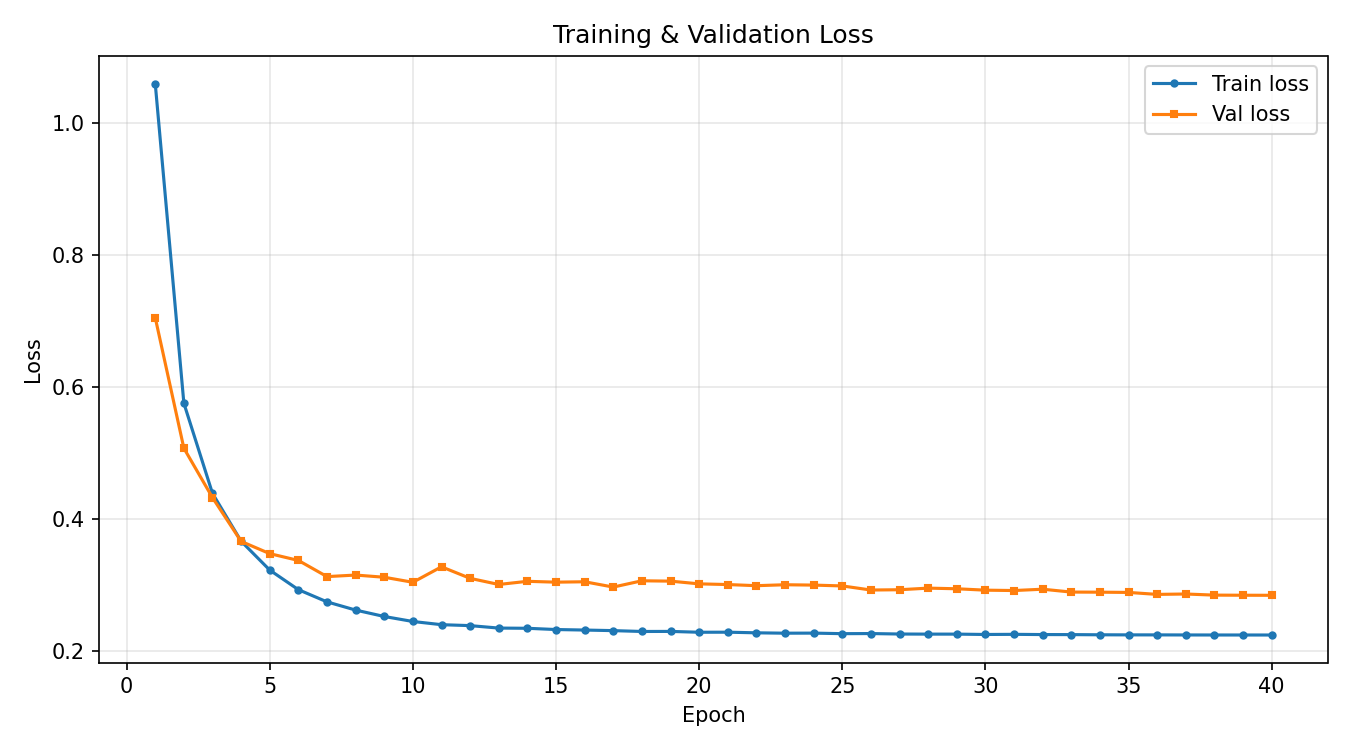


-- f1_curves.png --


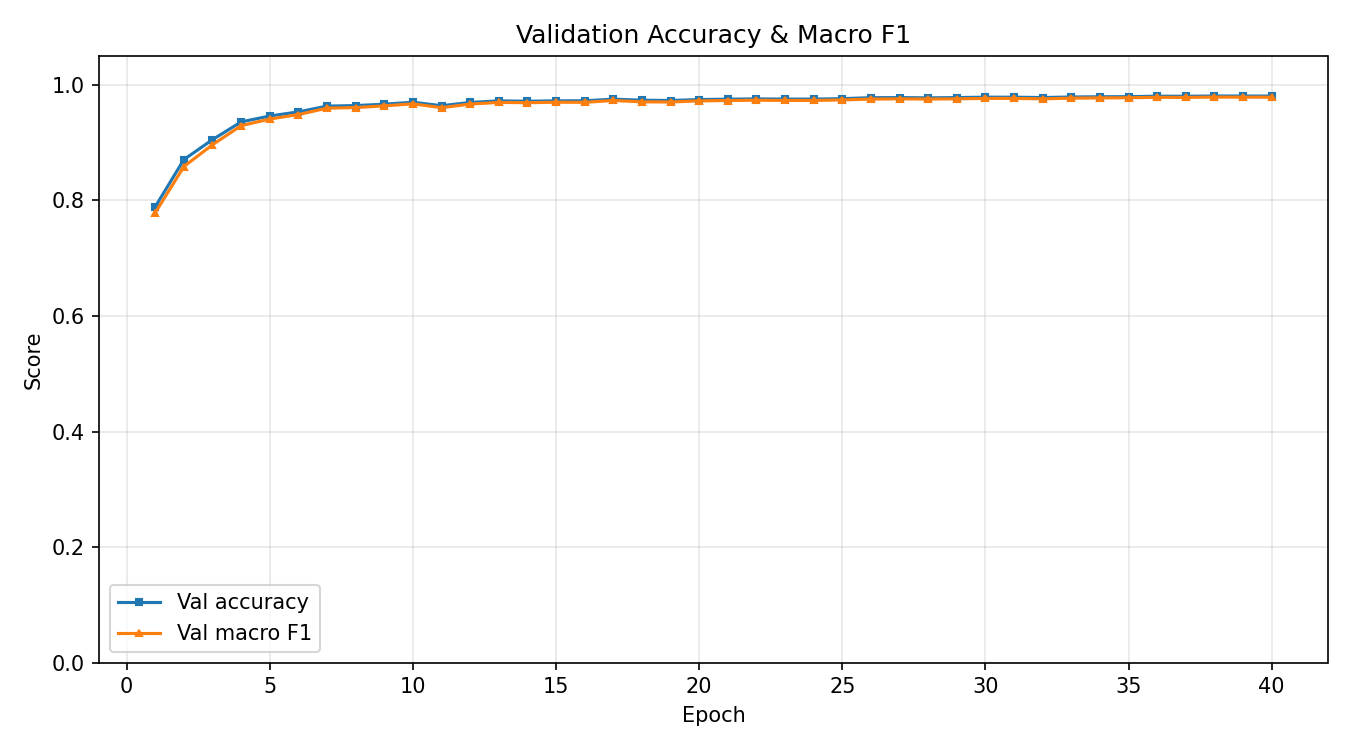


-- cm_val_dyn_abs.png --


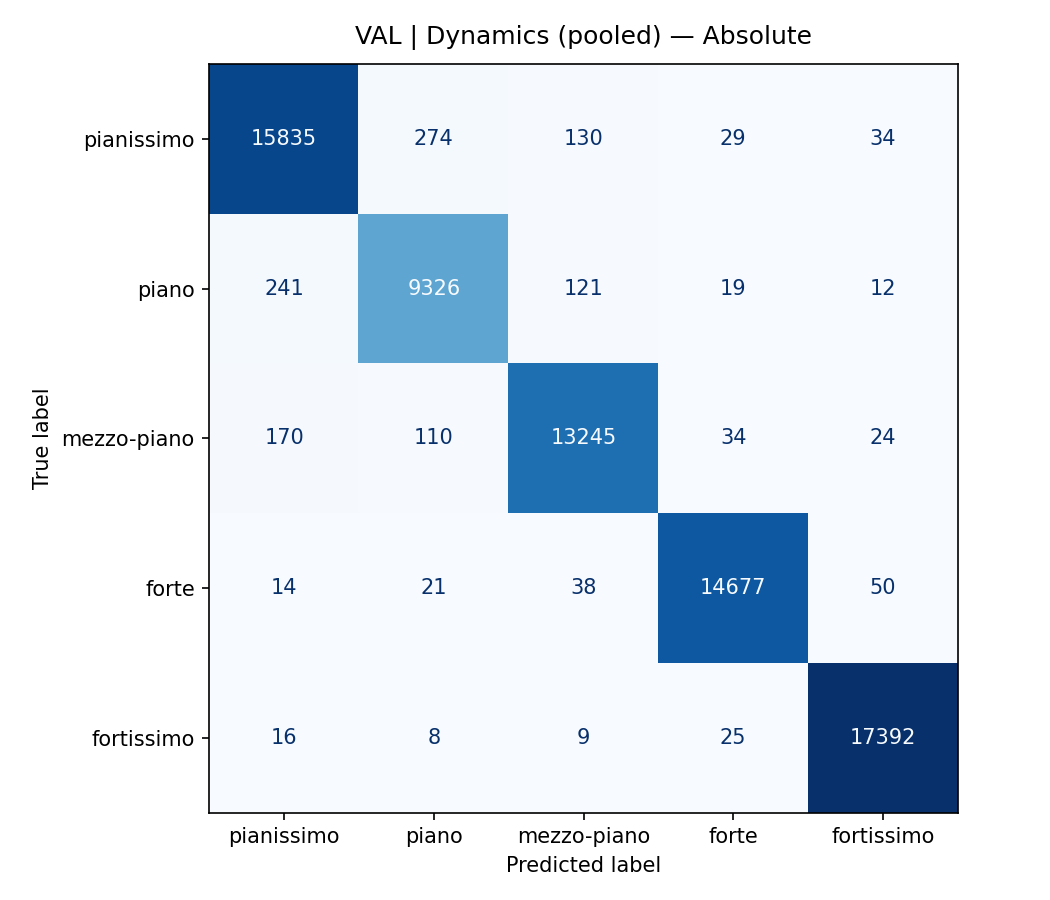


-- cm_val_dyn_norm.png --


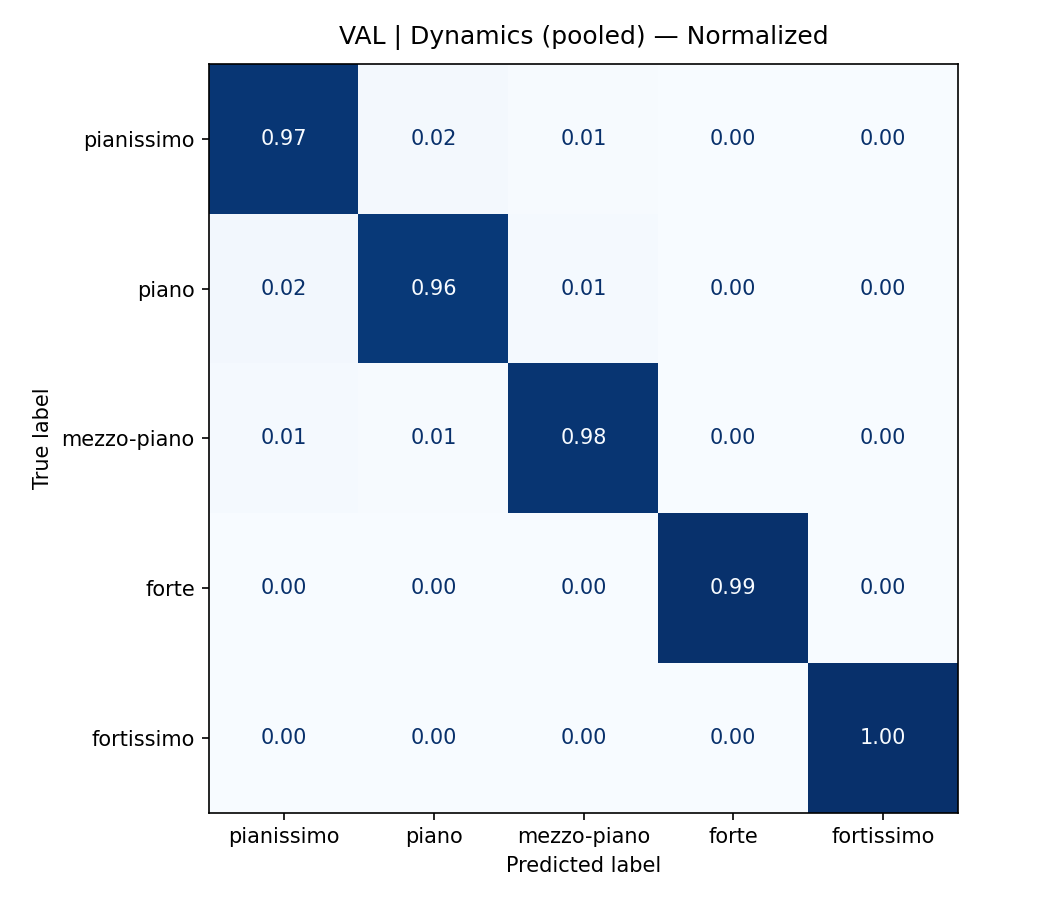


-- cm_test_dyn_abs.png --


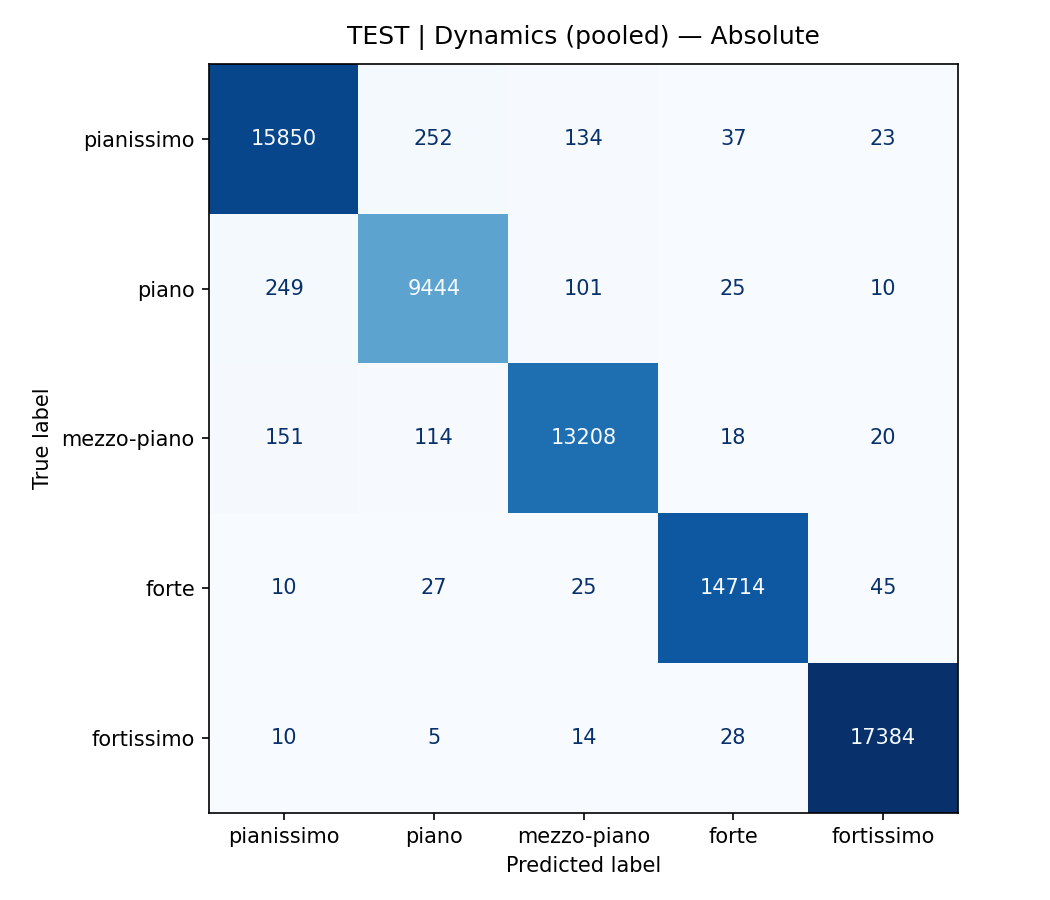


-- cm_test_dyn_norm.png --


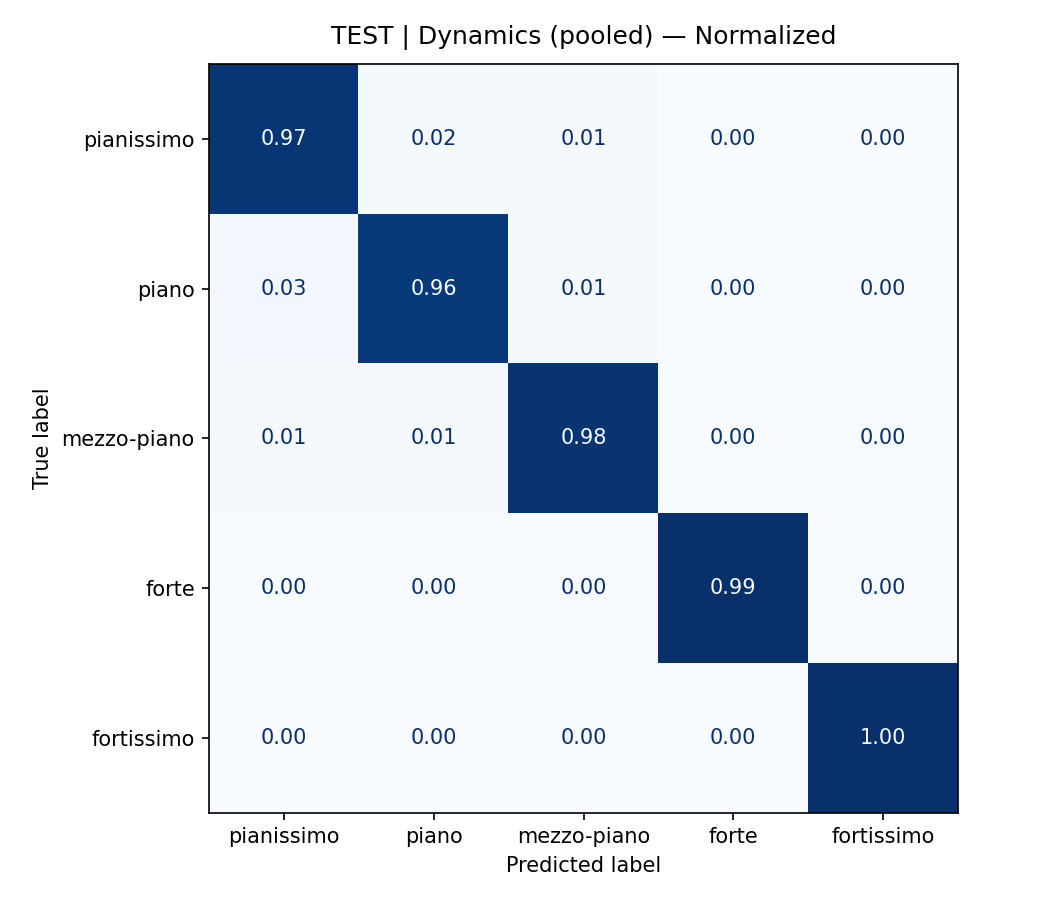


-- cm_val_dyn_cello_abs.png --


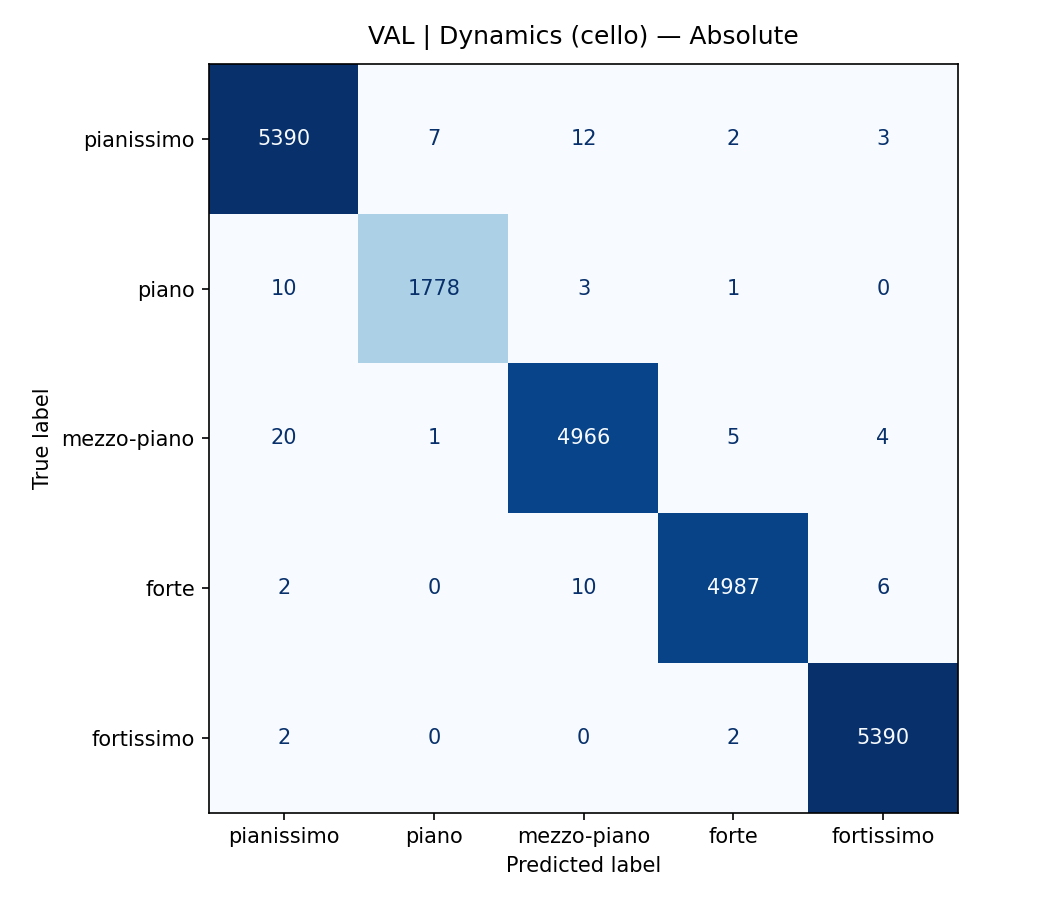


-- cm_val_dyn_cello_norm.png --


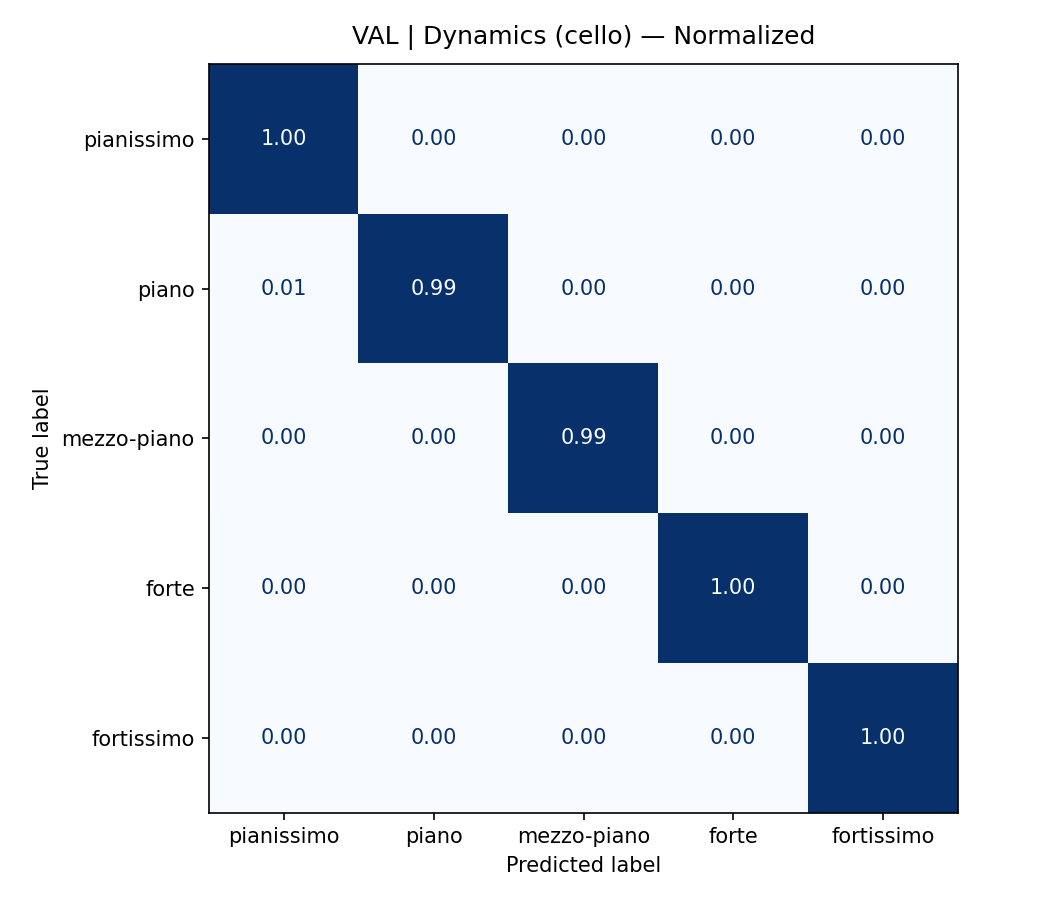


-- cm_val_dyn_viola_abs.png --


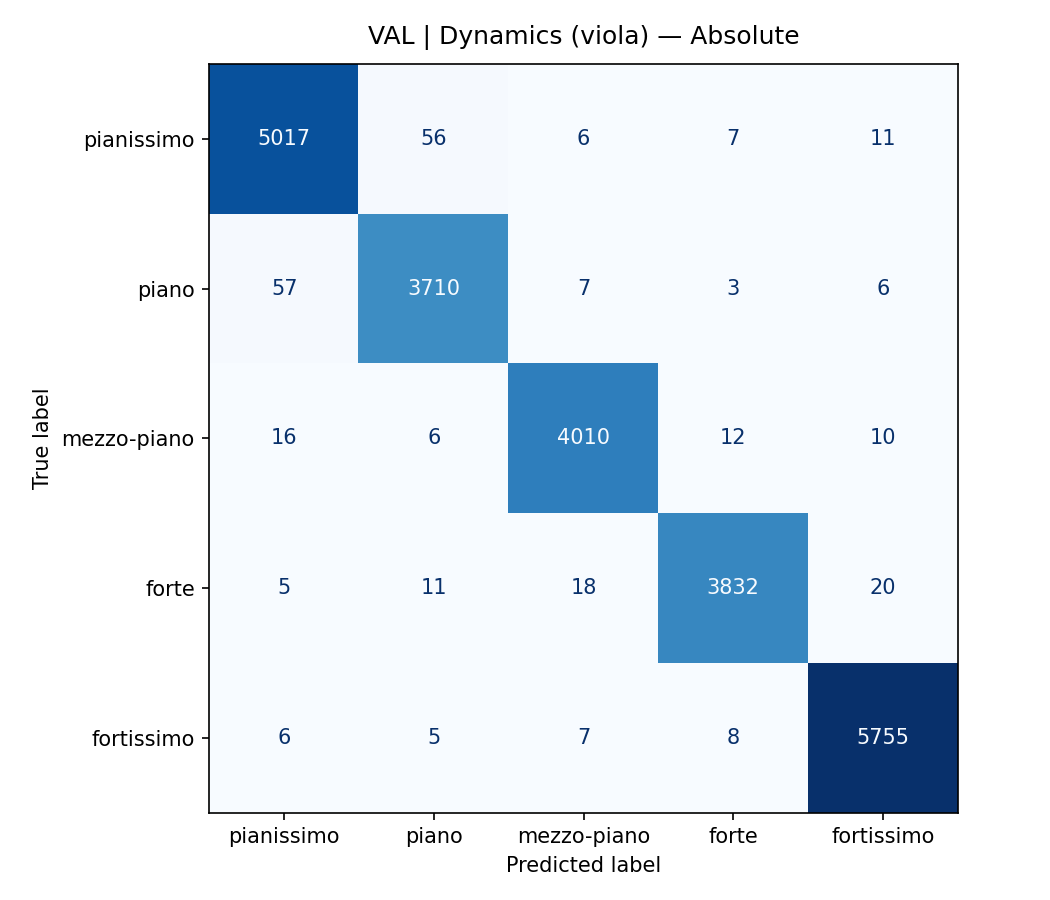


-- cm_val_dyn_viola_norm.png --


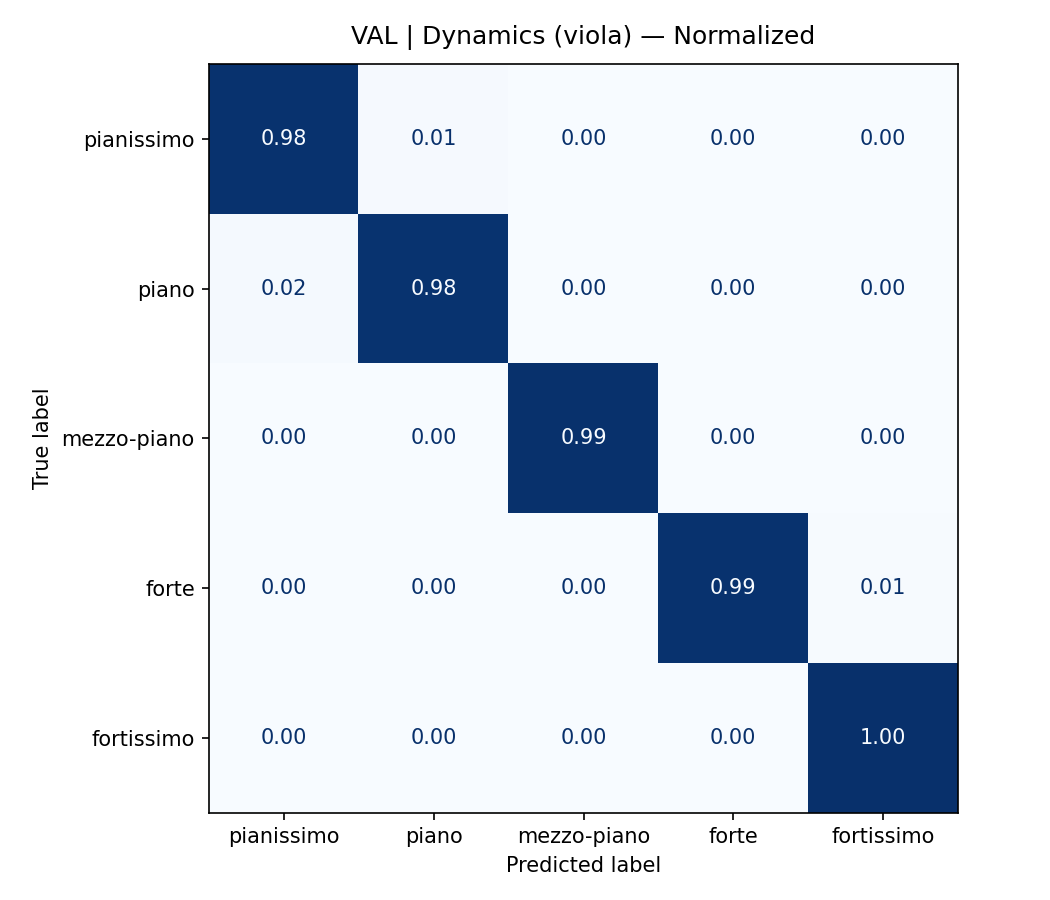


-- cm_val_dyn_violin2_abs.png --


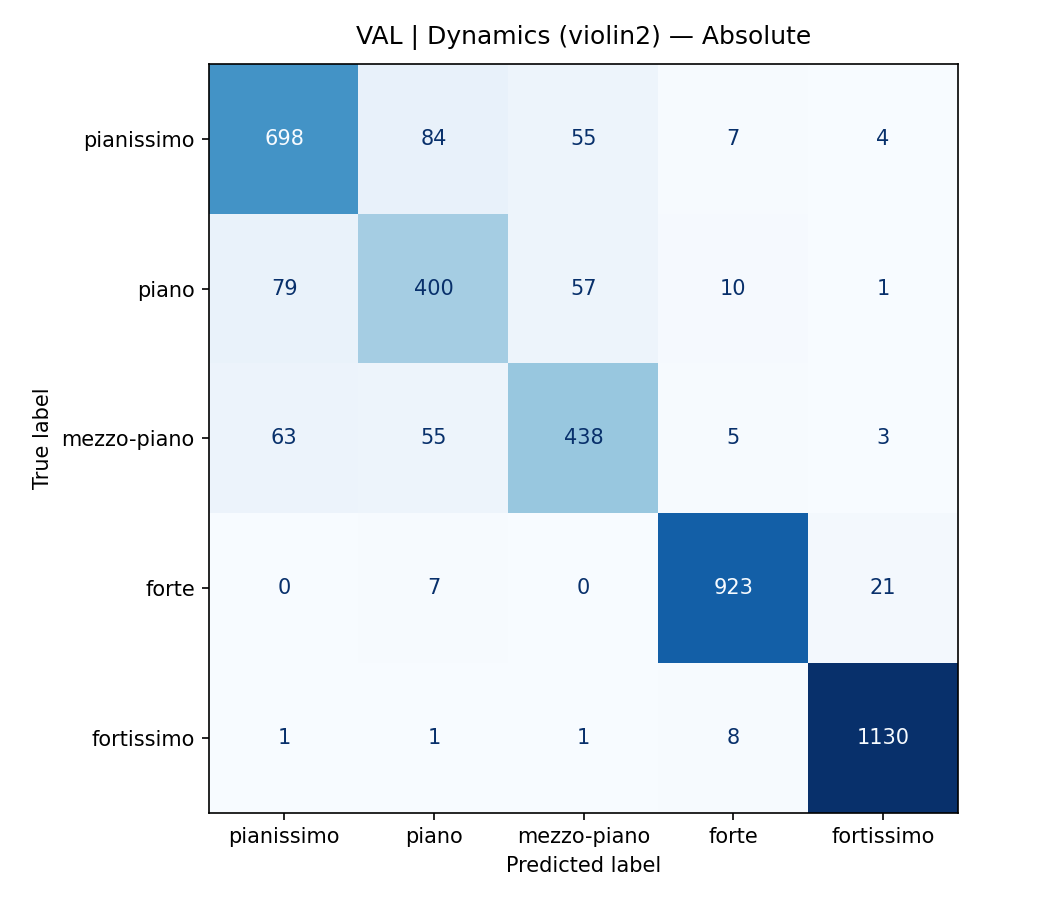


-- cm_val_dyn_violin2_norm.png --


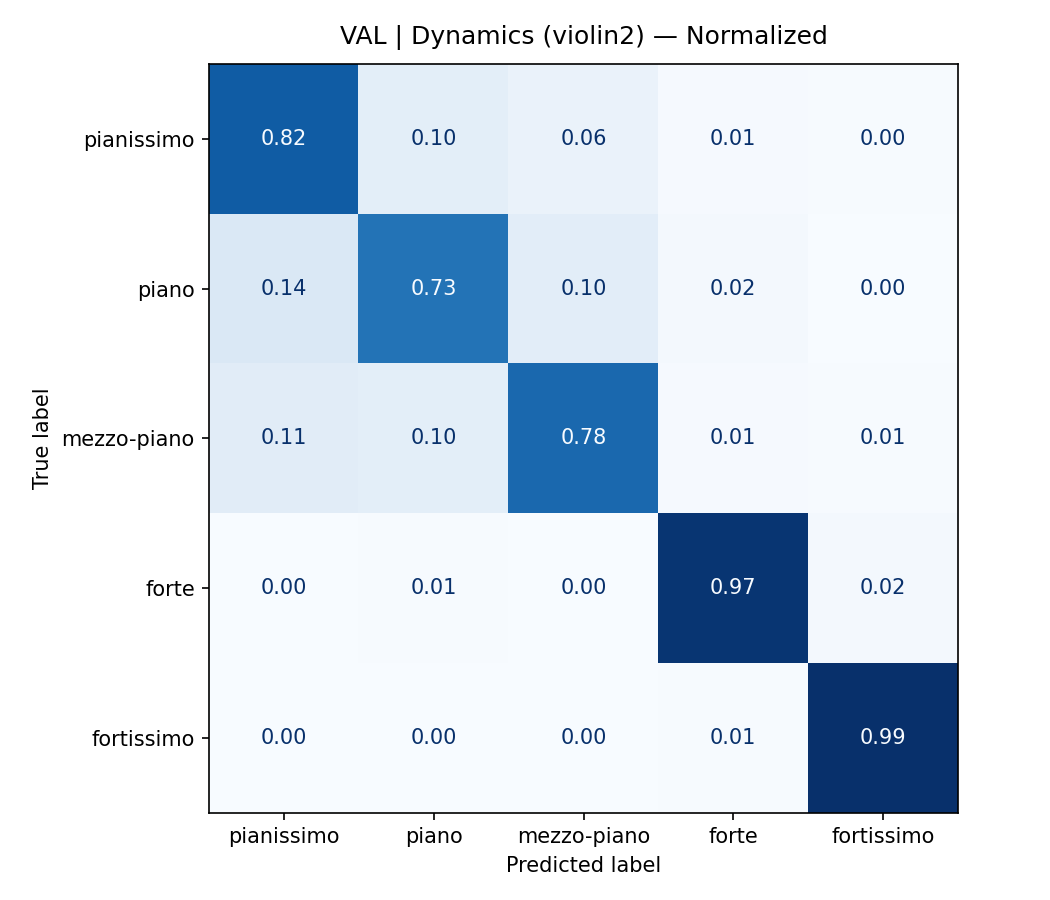


-- cm_val_dyn_violin1_abs.png --


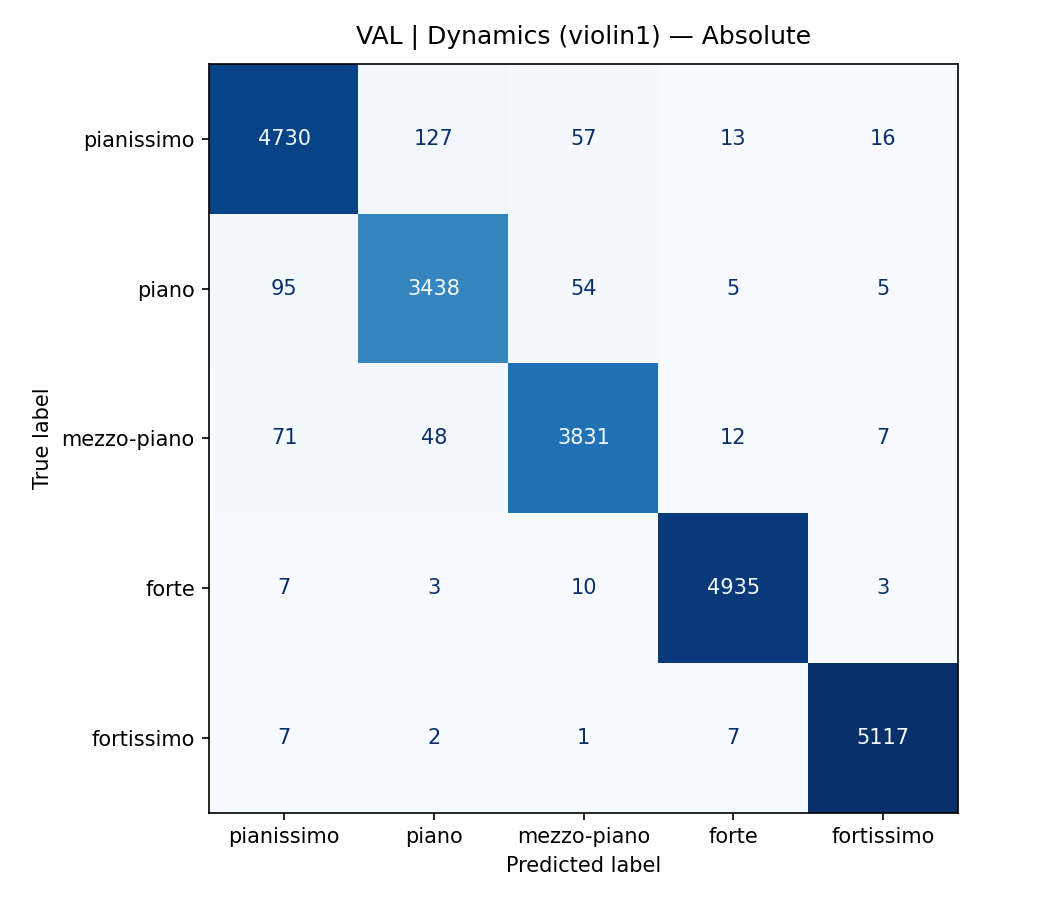


-- cm_val_dyn_violin1_norm.png --


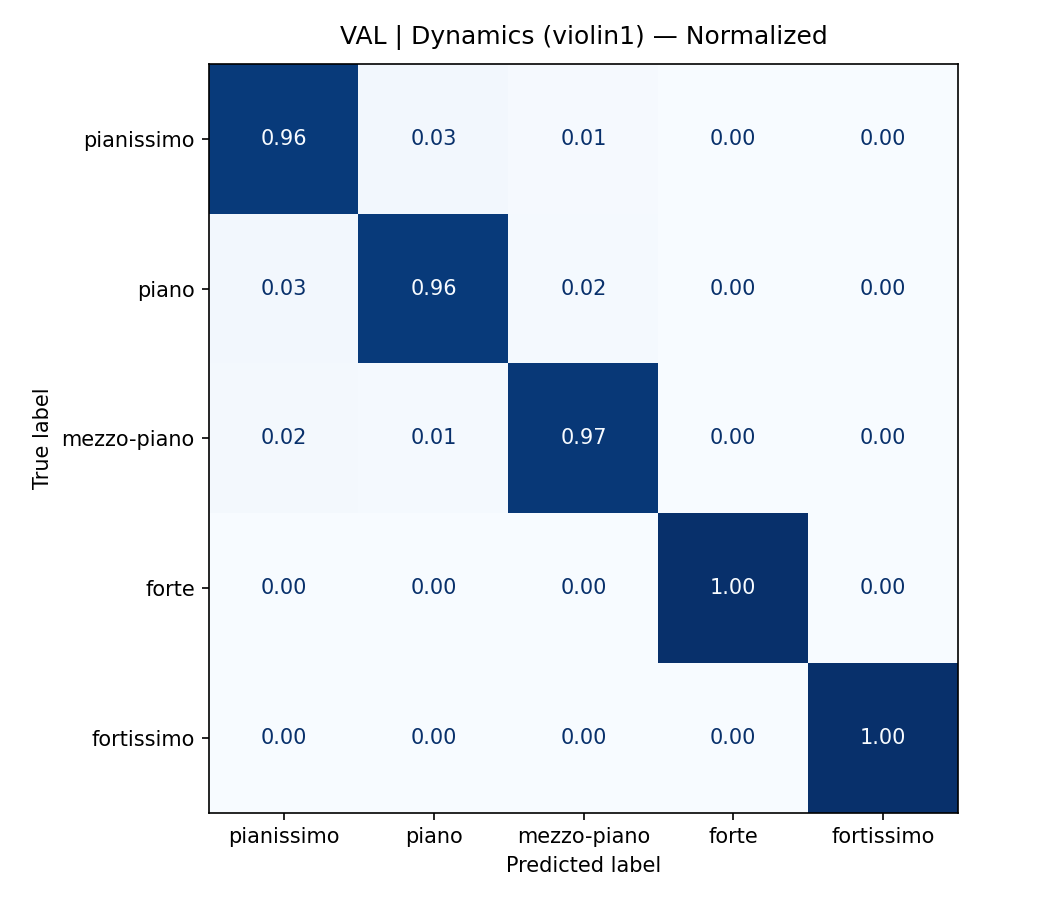


-- cm_test_dyn_cello_abs.png --


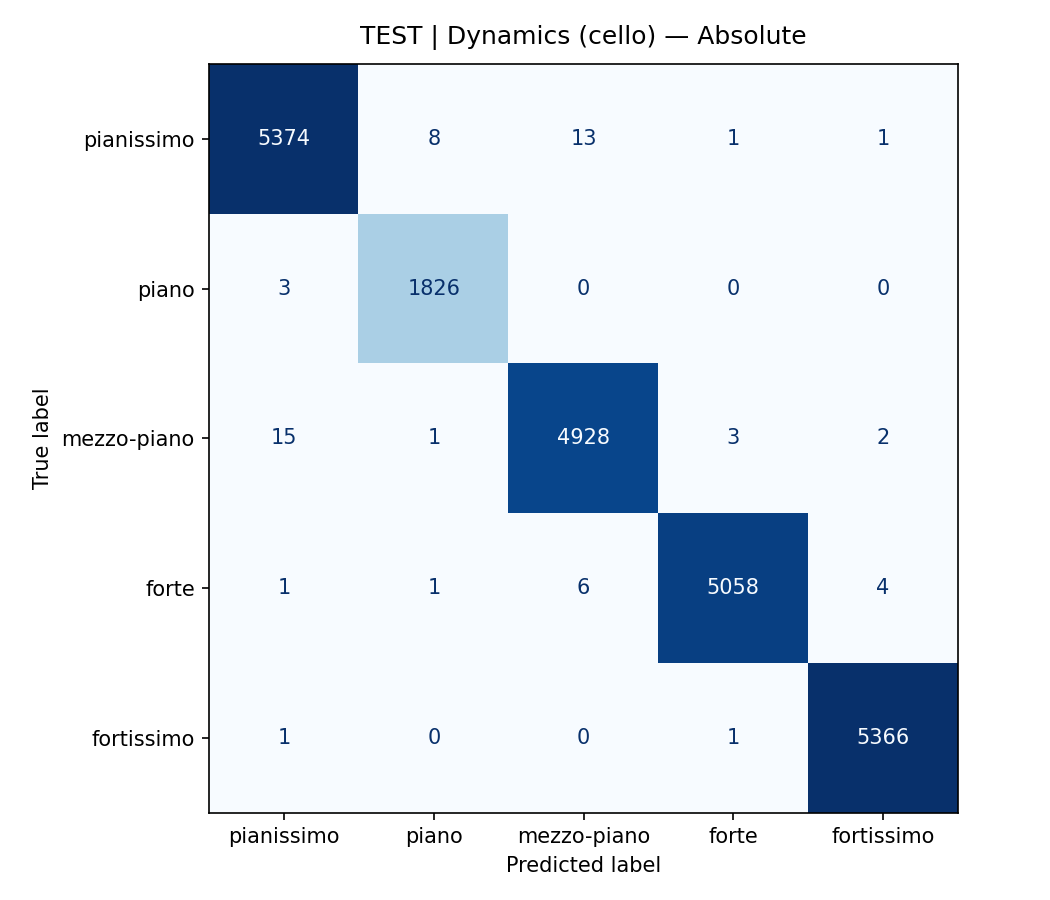


-- cm_test_dyn_cello_norm.png --


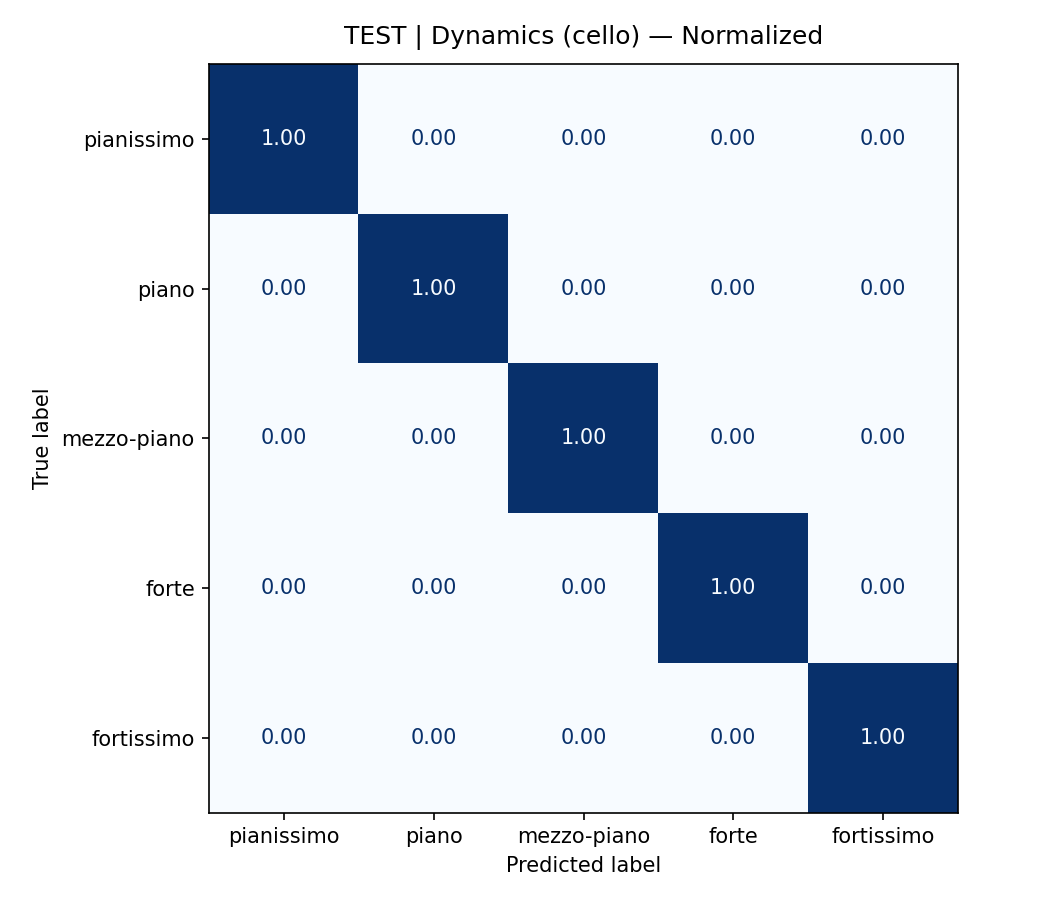


-- cm_test_dyn_viola_abs.png --


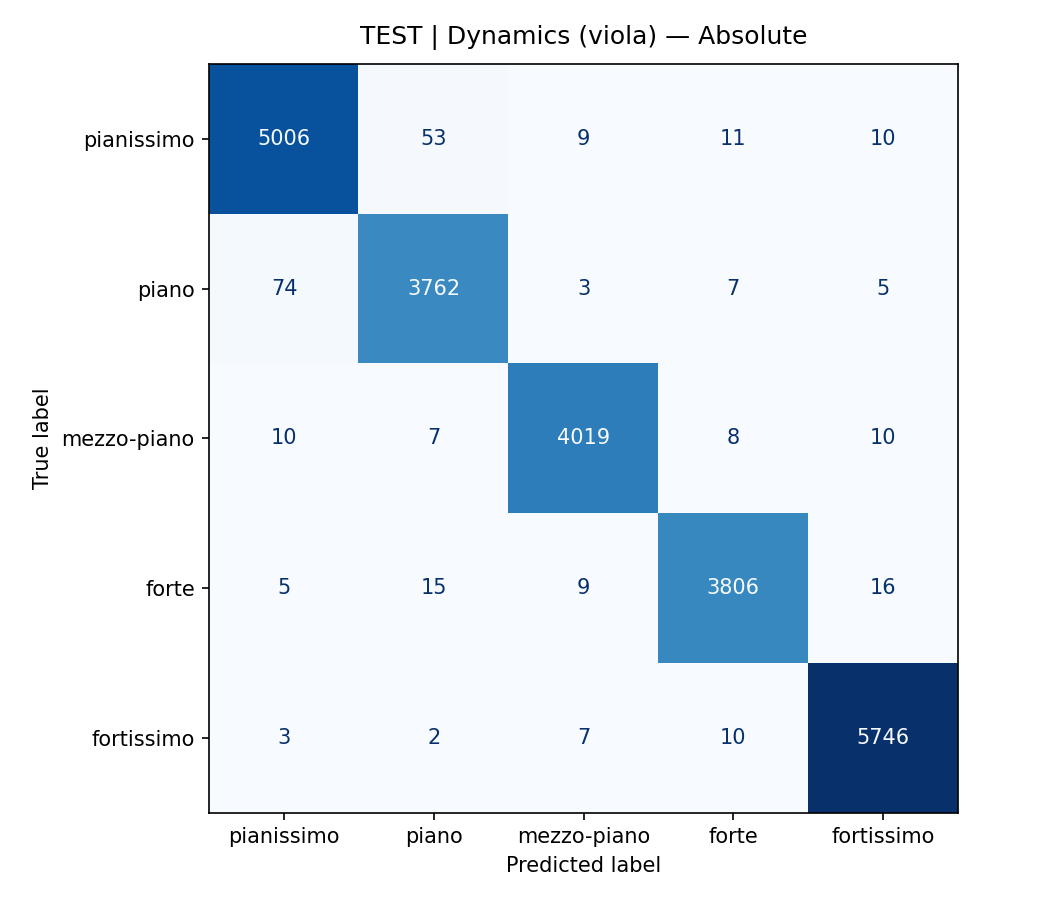


-- cm_test_dyn_viola_norm.png --


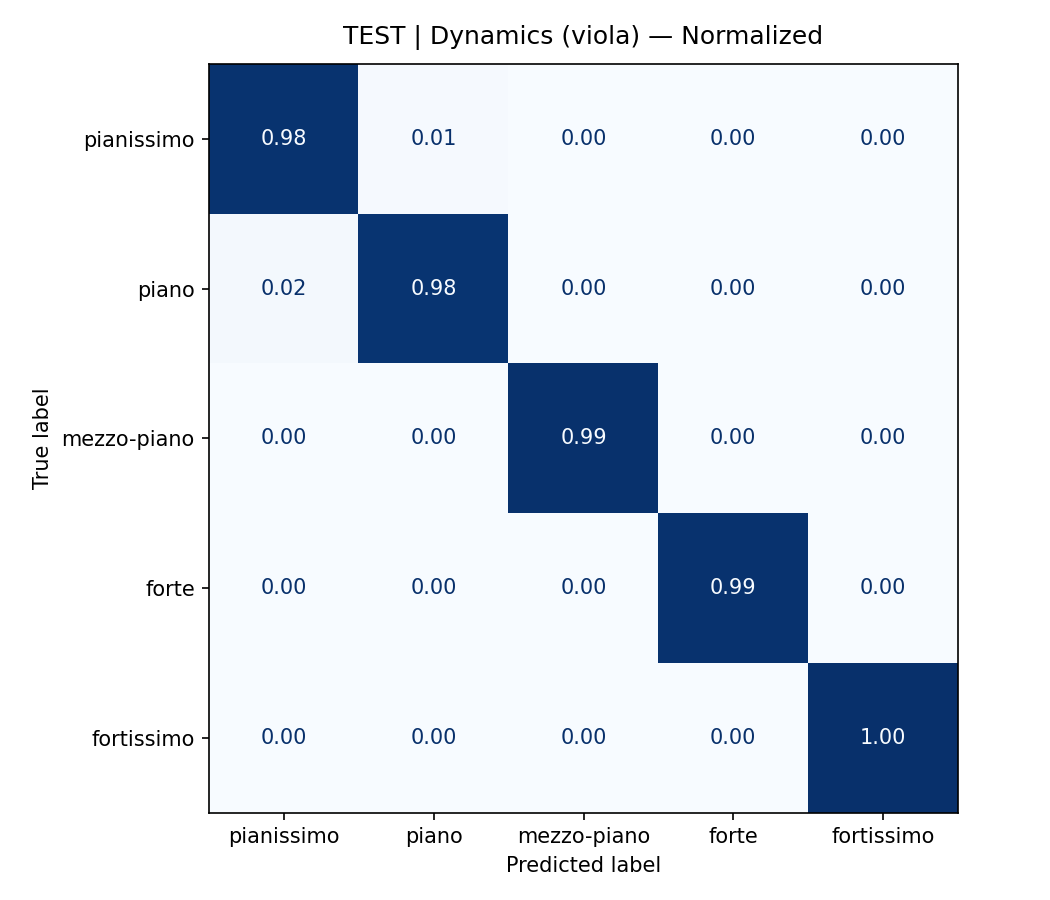


-- cm_test_dyn_violin2_abs.png --


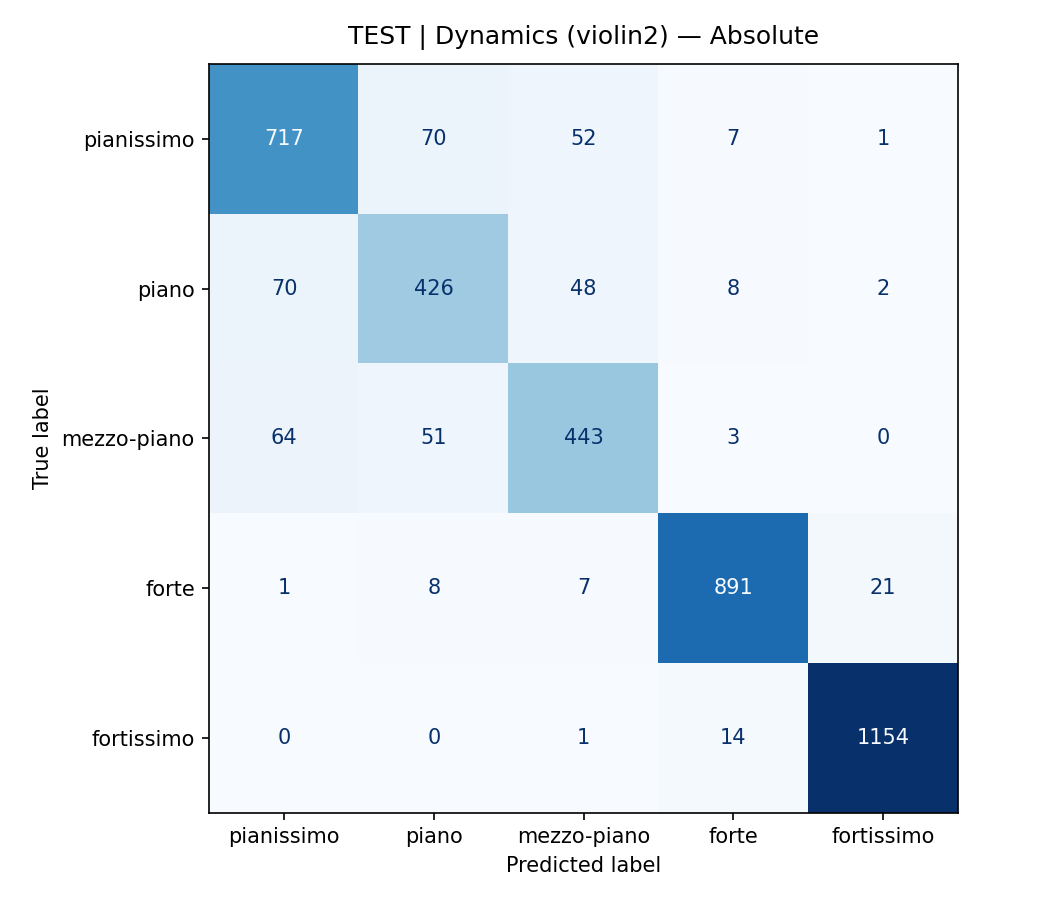


-- cm_test_dyn_violin2_norm.png --


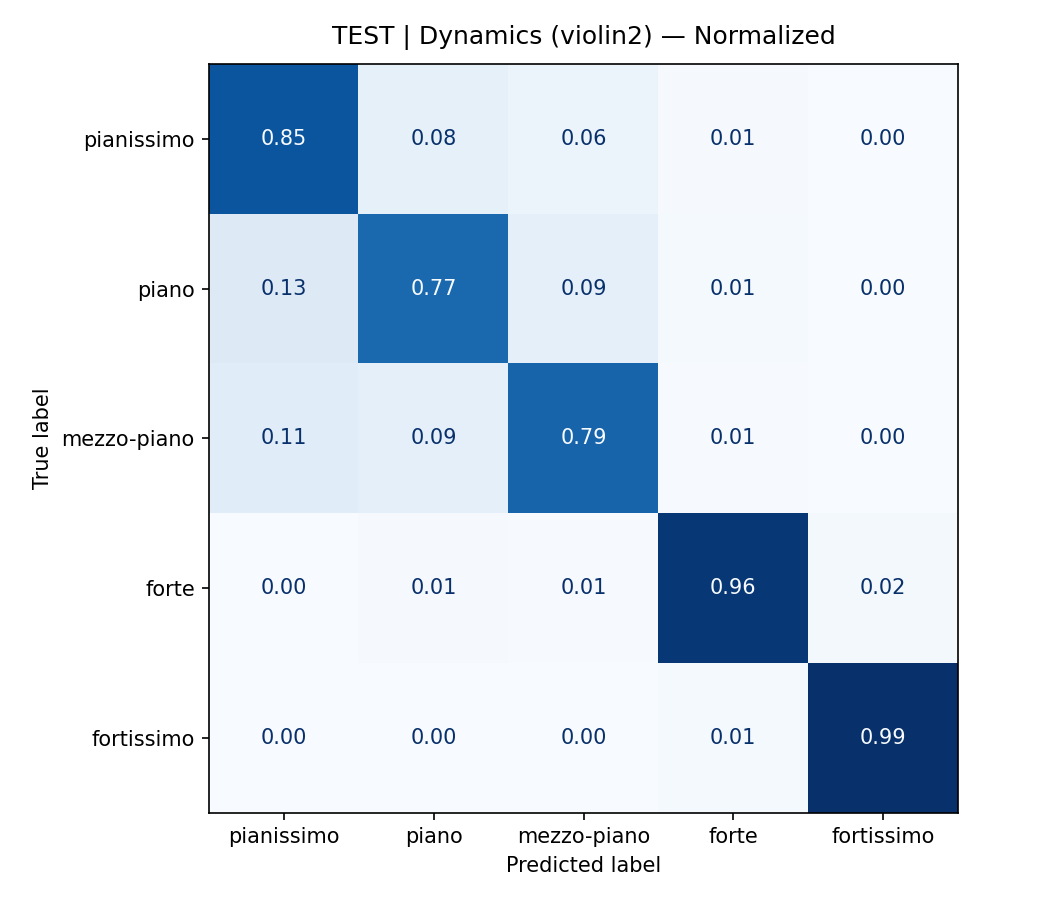


-- cm_test_dyn_violin1_abs.png --


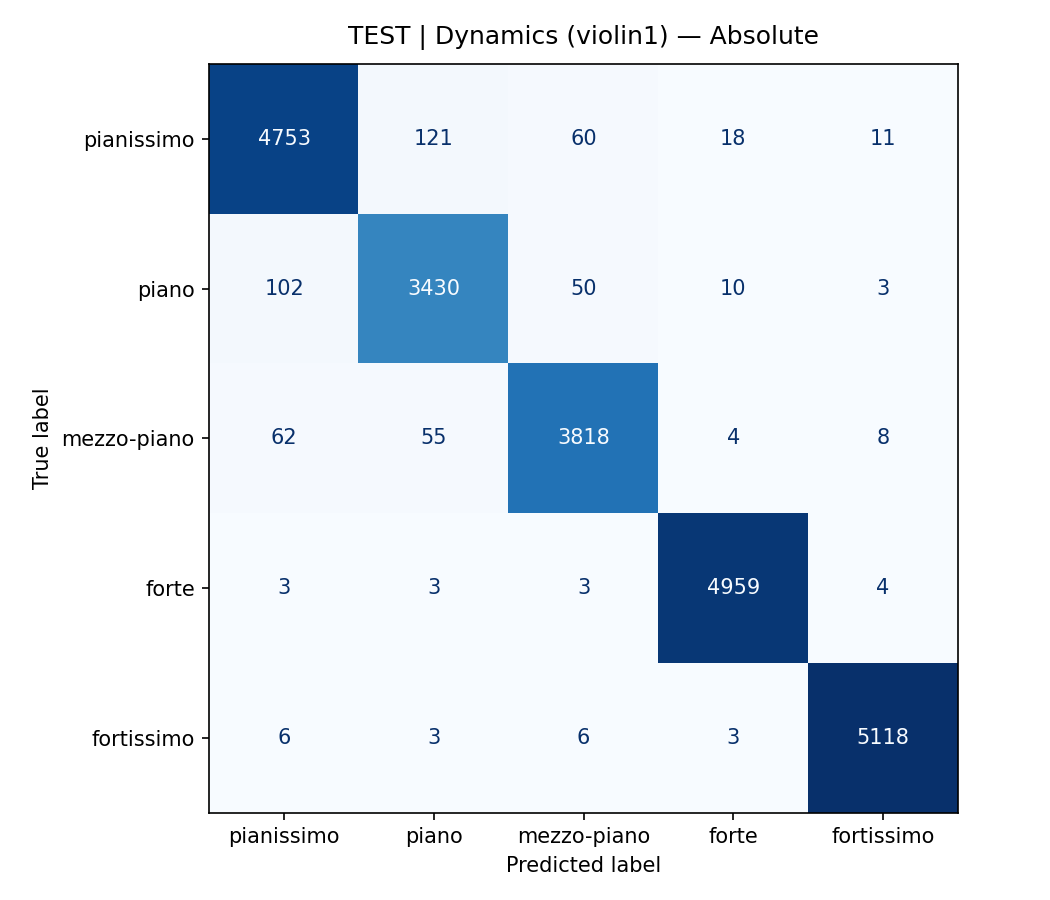


-- cm_test_dyn_violin1_norm.png --


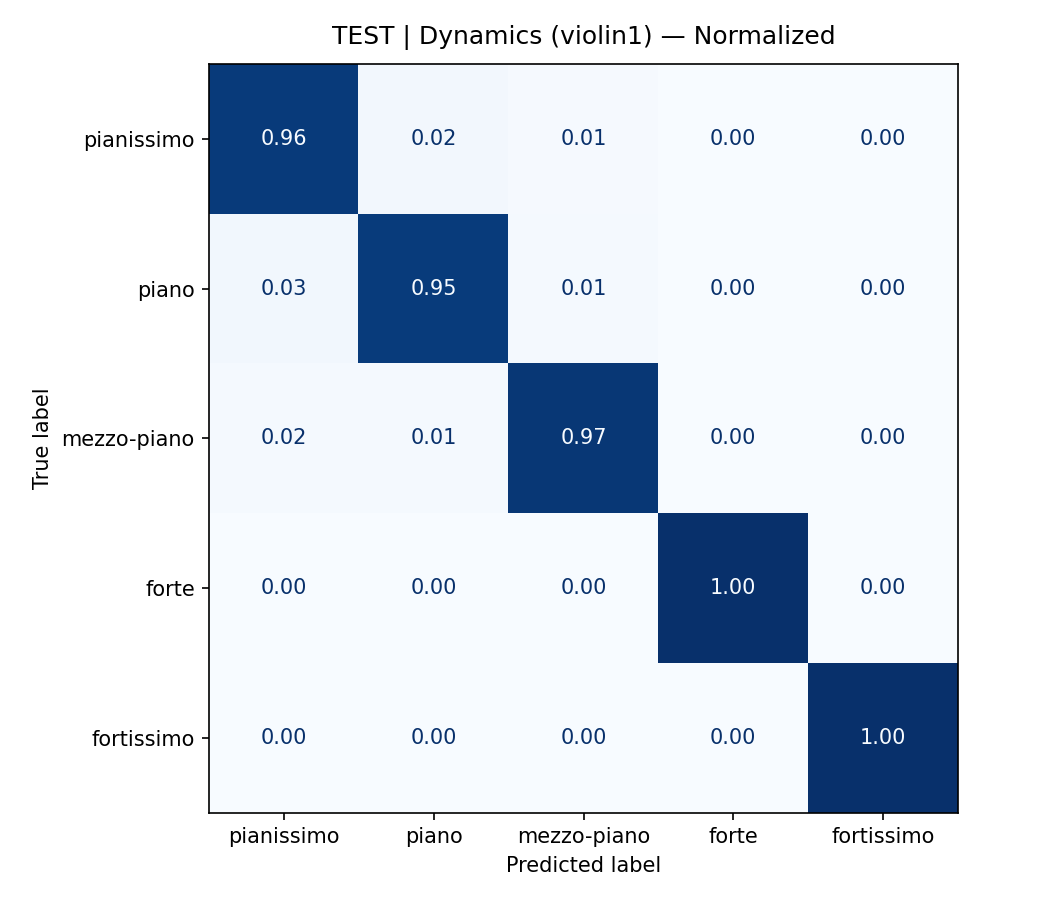

In [ ]:
# Cell 13.1 — Artifact Preview (Dynamics-only + per-instrument)

from IPython.display import display, Image as IPImage
import os

ARTIFACT_DIR = os.path.join(OUTDIR, "artifacts")

if not os.path.isdir(ARTIFACT_DIR):
    raise RuntimeError(f"Artifacts directory not found: {ARTIFACT_DIR}")

CORE_PLOTS = [
    "loss_curves.png",
    "f1_curves.png",
]

POOLED_CM = [
    "cm_val_dyn_abs.png",
    "cm_val_dyn_norm.png",
    "cm_test_dyn_abs.png",
    "cm_test_dyn_norm.png",
]

INSTRUMENTS = ["cello", "viola", "violin2", "violin1"]

def build_instr_cm(split):
    return [
        f"cm_{split}_dyn_{inst}_{kind}.png"
        for inst in INSTRUMENTS
        for kind in ["abs", "norm"]
    ]

INSTR_CM = build_instr_cm("val") + build_instr_cm("test")

PNG_ORDER = CORE_PLOTS + POOLED_CM + INSTR_CM

print("\n" + "=" * 70)
print("  Artifact Preview — Dynamics (pooled + per-instrument)")
print("=" * 70)

missing = []

for fname in PNG_ORDER:
    fpath = os.path.join(ARTIFACT_DIR, fname)
    if os.path.isfile(fpath):
        print(f"\n-- {fname} --")
        display(IPImage(filename=fpath))
    else:
        missing.append(fname)

if missing:
    print("\n" + "-" * 70)
    print("Missing artifacts:")
    for m in missing:
        print(f"  {m}")

In [ ]:
import os
found = sum(1 for _, r in df_all.head(100).iterrows() if os.path.exists(r["cachefile"]))
print(f"Found: {found}/100")
print(f"Sample path: {df_all.iloc[0]['cachefile']}")

# Also show what actually exists in that directory
cache_dir = os.path.dirname(df_all.iloc[0]["cachefile"])
print(f"\nExpected dir: {cache_dir}")
print(f"Dir exists: {os.path.isdir(cache_dir)}")
if os.path.isdir(cache_dir):
    files = os.listdir(cache_dir)
    print(f"Files in dir: {len(files)}")
    for f in files[:3]:
        print(f"  {f}")

Found: 100/100
Sample path: /home/aggelosger/mel_cache_ast16k_256/harmonic_intervals_loose/cello_viola_loose/135309_235419.npy

Expected dir: /home/aggelosger/mel_cache_ast16k_256/harmonic_intervals_loose/cello_viola_loose
Dir exists: True
Files in dir: 30000
  145409_259809.npy
  105409_214804.npy
  129617_246804.npy
